In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from rich import print
import folium
import geopandas as gpd
import contextily as ctx

In [8]:
DATA_DIR = "../data/external/LargeST/data/sd/largest/"

## EDA on 2017 traffic data

In [9]:
df_2017 = pd.read_hdf(os.path.join(DATA_DIR, "sd_his_2017.h5"))

In [10]:
df_2017

,1114091,1118333,1118348,1114720,1118352,1118743,1120362,1118796,1118735,1118450,...,1125829,1125348,1125353,1125359,1123287,1123276,1122394,1123261,1123256,1122412
Time,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,27.0,28.0,31.0,58.0,24.0,52.0,32.0,32.0,51.0,62.0,...,27.0,23.0,26.0,48.0,11.0,39.0,9.0,10.0,10.0,40.0
2017-01-01 00:05:00,26.0,21.0,17.0,53.0,20.0,48.0,33.0,36.0,60.0,45.0,...,26.0,26.0,28.0,56.0,13.0,38.0,11.0,10.0,14.0,42.0
2017-01-01 00:10:00,17.0,16.0,22.0,64.0,31.0,84.0,51.0,59.0,90.0,71.0,...,17.0,24.0,25.0,51.0,12.0,39.0,14.0,17.0,16.0,45.0
2017-01-01 00:15:00,24.0,22.0,34.0,65.0,35.0,102.0,73.0,92.0,118.0,112.0,...,31.0,20.0,19.0,43.0,15.0,40.0,17.0,11.0,11.0,36.0
2017-01-01 00:20:00,31.0,23.0,18.0,73.0,44.0,95.0,65.0,71.0,114.0,97.0,...,21.0,23.0,21.0,42.0,8.0,35.0,3.0,5.0,6.0,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 23:35:00,53.0,35.0,30.0,35.0,29.0,88.0,74.0,78.0,81.0,99.0,...,28.0,29.0,30.0,82.0,38.0,65.0,39.0,21.0,62.0,20.0
2017-12-31 23:40:00,55.0,32.0,30.0,37.0,30.0,93.0,72.0,76.0,75.0,73.0,...,49.0,56.0,58.0,68.0,31.0,54.0,29.0,22.0,63.0,27.0
2017-12-31 23:45:00,66.0,37.0,35.0,42.0,42.0,92.0,74.0,67.0,80.0,81.0,...,40.0,32.0,38.0,69.0,24.0,53.0,28.0,25.0,59.0,24.0


<span style="color: hotpink;">Each column corresponds to a sensor, and the name of the column is the ID of the sensor.</span>

In [11]:
df_2017.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 105120 entries, 2017-01-01 00:00:00 to 2017-12-31 23:55:00
Columns: 716 entries, 1114091 to 1122412
dtypes: float64(716)
memory usage: 575.0 MB


In [12]:
df_2017.describe()

,1114091,1118333,1118348,1114720,1118352,1118743,1120362,1118796,1118735,1118450,...,1125829,1125348,1125353,1125359,1123287,1123276,1122394,1123261,1123256,1122412
count,105107.000000,105106.000000,105106.000000,105108.000000,105108.000000,105108.000000,105106.000000,105105.000000,105108.000000,105106.000000,...,105105.000000,105105.000000,105105.000000,105106.000000,105106.000000,105106.000000,105105.000000,105106.000000,105106.000000,105106.000000
mean,132.136290,67.617910,83.479858,134.685219,131.355368,252.262739,249.568845,260.586480,283.974388,292.715991,...,131.970791,121.896542,126.436659,173.103438,101.589947,126.918891,94.155806,80.586770,93.210825,62.248054
std,37.947877,21.499454,29.436045,52.716050,59.716763,111.585073,127.097726,134.044088,146.823980,148.443732,...,62.388454,62.589723,65.683578,78.091191,50.186106,54.036077,44.854027,35.104893,38.249164,25.759430
min,0.000000,0.000000,2.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,109.000000,55.000000,62.000000,92.000000,80.000000,157.000000,128.000000,133.000000,145.000000,153.000000,...,85.000000,75.000000,77.000000,115.000000,63.000000,85.000000,60.000000,54.000000,71.000000,46.000000
50%,137.000000,69.000000,90.000000,148.000000,144.000000,277.000000,277.000000,290.000000,318.000000,327.000000,...,129.000000,119.000000,123.000000,170.000000,103.000000,126.000000,98.000000,87.000000,98.000000,62.000000
75%,158.000000,82.000000,105.000000,173.000000,170.000000,327.000000,355.000000,370.000000,403.000000,414.000000,...,169.000000,158.000000,164.000000,219.000000,133.000000,160.000000,124.000000,106.000000,115.000000,77.000000
max,779.000000,189.000000,215.000000,553.000000,384.000000,576.000000,619.000000,683.000000,707.000000,758.000000,...,411.000000,404.000000,424.000000,513.000000,331.000000,401.000000,263.000000,213.000000,408.000000,155.000000


In [13]:
df_2017.index

DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 00:05:00',
               '2017-01-01 00:10:00', '2017-01-01 00:15:00',
               '2017-01-01 00:20:00', '2017-01-01 00:25:00',
               '2017-01-01 00:30:00', '2017-01-01 00:35:00',
               '2017-01-01 00:40:00', '2017-01-01 00:45:00',
               ...
               '2017-12-31 23:10:00', '2017-12-31 23:15:00',
               '2017-12-31 23:20:00', '2017-12-31 23:25:00',
               '2017-12-31 23:30:00', '2017-12-31 23:35:00',
               '2017-12-31 23:40:00', '2017-12-31 23:45:00',
               '2017-12-31 23:50:00', '2017-12-31 23:55:00'],
              dtype='datetime64[ns]', name='Time', length=105120, freq=None)

<span style="color: hotpink;">The index of the dataframe is the timestamp of the traffic data</span>

In [14]:
df_2017.index.diff().value_counts()

Time
0 days 00:05:00    105119
Name: count, dtype: int64

<span style="color: hotpink;"> No other timestamps are missing, and the data is recorded every 5 minutes.</span>

In [15]:
meta_df = pd.read_csv(os.path.join(DATA_DIR, "sd_meta.csv"))

In [16]:
meta_df

,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,1114091,32.544463,-117.032486,11,San Diego,I5-N,6,Mainline,N,6931
1,1118333,32.551690,-117.045725,11,San Diego,I5-N,4,Mainline,N,6932
2,1118348,32.558459,-117.061845,11,San Diego,I5-N,4,Mainline,N,6933
3,1114720,32.561334,-117.067081,11,San Diego,I5-N,4,Mainline,N,6934
4,1118352,32.569052,-117.076507,11,San Diego,I5-N,4,Mainline,N,6935
...,...,...,...,...,...,...,...,...,...,...
711,1123276,32.564373,-116.969279,11,San Diego,I905-W,3,Mainline,W,7642
712,1122394,32.564336,-116.961909,11,San Diego,I905-W,3,Mainline,W,7643
713,1123261,32.564112,-116.950744,11,San Diego,I905-W,3,Mainline,W,7644
714,1123256,32.560935,-116.944559,11,San Diego,I905-W,3,Mainline,W,7645


In [17]:
meta_df[["District", "County"]].value_counts()

District  County   
11        San Diego    716
Name: count, dtype: int64

In [18]:
meta_df['ID'].nunique()

716

<span style="color: red;">Are there any orphan sensors that are not associated with any district or county?</span>

In [19]:
id_entries = set(meta_df['ID'])
data_entries = set(df_2017.columns.astype(int))

missing_in_df = id_entries - data_entries

print(f"[hot_pink]Number of sensors in meta_df but not in df_2017: [bold]{len(missing_in_df)}[/bold][/hot_pink]")
print(f"[hot_pink]Are all sensors in meta_df also in df_2017? [bold]{id_entries.issubset(data_entries)}[/bold][/hot_pink]")

Number of sensors in meta_df but not in df_2017: 0

Are all sensors in meta_df also in df_2017? True

In [20]:
def check_orphan_sensors(meta_df, sensors, year):
    # Get the set of sensor IDs from the meta_df
    meta_sensor_ids = set(meta_df['ID'])
    
    # Get the set of sensor IDs from the sensors list
    sensor_ids = set(sensors.astype(int))
    
    # Find orphan sensors (those in meta_df but not in sensors)
    orphan_sensors = meta_sensor_ids - sensor_ids
    
    print(f"[hot_pink]Number of sensors in meta_df but not in df_{year}: [bold]{len(orphan_sensors)}[/bold][/hot_pink]")
    print(f"[hot_pink]Are all sensors in meta_df also in df_{year}? [bold]{meta_sensor_ids.issubset(sensor_ids)}[/bold][/hot_pink]")

In [21]:
check_orphan_sensors(meta_df, df_2017.columns, 2017)

Number of sensors in meta_df but not in df_2017: 0

Are all sensors in meta_df also in df_2017? True

<span style="color: hotpink;">Plot the sensors on a map of San Diego</span>

In [22]:
mean_lat_lng = np.mean(meta_df[["Lat", "Lng"]], axis=0)
# Convert to tuple for folium
mean_lat_lng = tuple(mean_lat_lng)

In [23]:
mean_lat_lng

(32.8574131424581, -117.13375297067039)

In [24]:
map_plot = folium.Map(location=mean_lat_lng, zoom_start=10)

# Add sensor locations to the map
for _, row in meta_df.iterrows():
    folium.Marker(location=[row["Lat"], row["Lng"]], popup=f"ID: {row['ID']}").add_to(map_plot)

# Display the map
map_plot.save("sensor_map.html")

In [25]:
gdf = gpd.GeoDataFrame(
    meta_df,
    geometry=gpd.points_from_xy(meta_df.Lng, meta_df.Lat),
    crs="EPSG:4326"
)

url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
counties = gpd.read_file(url)

san_diego = counties[
    (counties["NAME"] == "San Diego") &
    (counties["STATEFP"] == "06")   # 06 = California
]

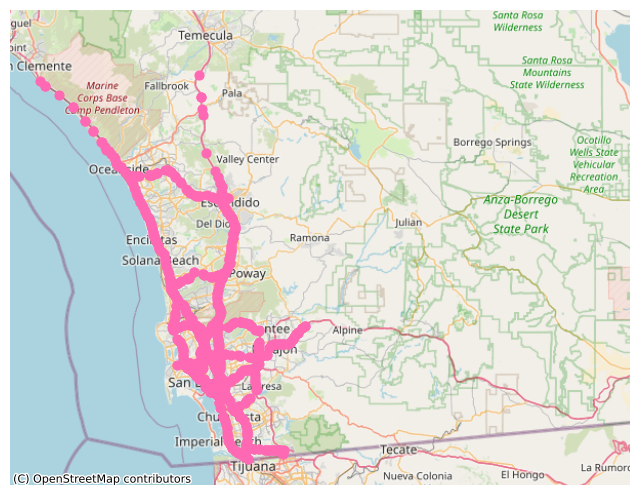

In [26]:
ax = san_diego.to_crs(epsg=3857).plot(figsize=(8, 8), alpha=0)

gdf_web = gdf.to_crs(epsg=3857)
gdf_web.plot(ax=ax, color="hotpink", markersize=40)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()

In [27]:
import holidays

In [28]:
california_holidays = holidays.US(subdiv="CA", years=[2017, 2018, 2019])

In [29]:
california_holidays

{datetime.date(2017, 1, 1): "New Year's Day", datetime.date(2017, 1, 2): "New Year's Day (observed)", datetime.date(2017, 5, 29): 'Memorial Day', datetime.date(2017, 7, 4): 'Independence Day', datetime.date(2017, 9, 4): 'Labor Day', datetime.date(2017, 11, 23): 'Thanksgiving Day', datetime.date(2017, 12, 25): 'Christmas Day', datetime.date(2017, 1, 16): 'Martin Luther King Jr. Day', datetime.date(2017, 11, 11): 'Veterans Day', datetime.date(2017, 11, 10): 'Veterans Day (observed)', datetime.date(2017, 2, 20): "Presidents' Day", datetime.date(2017, 2, 15): 'Susan B. Anthony Day', datetime.date(2017, 3, 31): 'Cesar Chavez Day', datetime.date(2017, 11, 24): 'Day After Thanksgiving', datetime.date(2018, 1, 1): "New Year's Day", datetime.date(2018, 5, 28): 'Memorial Day', datetime.date(2018, 7, 4): 'Independence Day', datetime.date(2018, 9, 3): 'Labor Day', datetime.date(2018, 11, 22): 'Thanksgiving Day', datetime.date(2018, 12, 25): 'Christmas Day', datetime.date(2018, 1, 15): 'Martin Luth

In [30]:
meta_df

,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,1114091,32.544463,-117.032486,11,San Diego,I5-N,6,Mainline,N,6931
1,1118333,32.551690,-117.045725,11,San Diego,I5-N,4,Mainline,N,6932
2,1118348,32.558459,-117.061845,11,San Diego,I5-N,4,Mainline,N,6933
3,1114720,32.561334,-117.067081,11,San Diego,I5-N,4,Mainline,N,6934
4,1118352,32.569052,-117.076507,11,San Diego,I5-N,4,Mainline,N,6935
...,...,...,...,...,...,...,...,...,...,...
711,1123276,32.564373,-116.969279,11,San Diego,I905-W,3,Mainline,W,7642
712,1122394,32.564336,-116.961909,11,San Diego,I905-W,3,Mainline,W,7643
713,1123261,32.564112,-116.950744,11,San Diego,I905-W,3,Mainline,W,7644
714,1123256,32.560935,-116.944559,11,San Diego,I905-W,3,Mainline,W,7645


In [31]:
meta_df['Type'].value_counts()

Type
Mainline    716
Name: count, dtype: int64

In [32]:
meta_df['Fwy'].value_counts()

Fwy
I5-N       95
I5-S       86
I15-N      69
I15-S      58
I805-S     51
I805-N     49
I8-W       47
I8-E       39
SR78-W     24
SR78-E     20
SR94-W     20
SR125-N    19
SR52-W     18
SR94-E     16
SR163-S    15
SR52-E     13
SR56-E     13
SR56-W     11
SR125-S    11
I905-E     11
I905-W     11
SR163-N    10
SR11-W      3
SR54-E      3
SR54-W      3
SR11-E      1
Name: count, dtype: int64

In [33]:
meta_df['Lanes'].value_counts()

Lanes
4    315
5    139
3    134
2     73
6     48
7      5
8      2
Name: count, dtype: int64

TODO:

- [x] Aggregate the sensor data by Fwy and Lanes and plot the average traffic volume for each group. This can help identify which freeways and lanes are more congested.
- [] Analyze the temporal patterns of traffic volume by plotting the average traffic volume for each hour of the day and each day of the week. This can help identify peak traffic hours and days.
- [] Analyze the spatial patterns of traffic volume by plotting the average traffic volume for each sensor location on a map of San Diego. This can help identify which areas of the city are more congested.
- [] Analyze the relationship between traffic volume and holidays by plotting the average traffic volume for each day of the year and highlighting the holidays. This can help identify if there are any significant changes in traffic volume during holidays.
- [] Identify any seasonal or trend patterns
- [] Cross analyse the traffic data for each year
- [] Correlation analysis between traffic volume and environmental factors such as weather conditions, air quality, and noise levels. This can help identify if there are any significant relationships between traffic volume and environmental factors.

In [47]:
meta = meta_df[meta_df["ID"].astype(str).isin(df_2017.columns)].copy()

In [48]:
meta

,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,1114091,32.544463,-117.032486,11,San Diego,I5-N,6,Mainline,N,6931
1,1118333,32.551690,-117.045725,11,San Diego,I5-N,4,Mainline,N,6932
2,1118348,32.558459,-117.061845,11,San Diego,I5-N,4,Mainline,N,6933
3,1114720,32.561334,-117.067081,11,San Diego,I5-N,4,Mainline,N,6934
4,1118352,32.569052,-117.076507,11,San Diego,I5-N,4,Mainline,N,6935
...,...,...,...,...,...,...,...,...,...,...
711,1123276,32.564373,-116.969279,11,San Diego,I905-W,3,Mainline,W,7642
712,1122394,32.564336,-116.961909,11,San Diego,I905-W,3,Mainline,W,7643
713,1123261,32.564112,-116.950744,11,San Diego,I905-W,3,Mainline,W,7644
714,1123256,32.560935,-116.944559,11,San Diego,I905-W,3,Mainline,W,7645


In [49]:
meta = meta.set_index("ID")

In [50]:
sensor_groups = meta[["Fwy", "Lanes"]]

In [51]:
sensor_groups

,Fwy,Lanes
ID,,
1114091,I5-N,6
1118333,I5-N,4
1118348,I5-N,4
1114720,I5-N,4
1118352,I5-N,4
...,...,...
1123276,I905-W,3
1122394,I905-W,3
1123261,I905-W,3


In [74]:
sensors_list = df_2017.columns.astype(str).to_list()
meta_ids = meta_df["ID"].astype(str).to_list()
# meta = meta_df.set_index("ID")
# meta = meta.loc[meta.index.intersection(df_2017.columns)]
# meta = meta.loc[df_2017.columns]

In [76]:
sensors_list == meta_ids

True

In [77]:
common_ids = list(set(sensors_list) & set(meta_ids))

print("Sensors in raw:", len(sensors_list))
print("Sensors in metadata:", len(meta_ids))
print("Common sensors:", len(common_ids))

Sensors in raw: 716

Sensors in metadata: 716

Common sensors: 716

In [78]:
df_raw_sub = df_2017[common_ids]

meta_sub = (
    meta_df[meta_df["ID"].astype(str).isin(common_ids)]
    .assign(ID=lambda x: x["ID"].astype(str))
    .set_index("ID")
)

In [79]:
meta_sub

,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
ID,,,,,,,,,
1114091,32.544463,-117.032486,11,San Diego,I5-N,6,Mainline,N,6931
1118333,32.551690,-117.045725,11,San Diego,I5-N,4,Mainline,N,6932
1118348,32.558459,-117.061845,11,San Diego,I5-N,4,Mainline,N,6933
1114720,32.561334,-117.067081,11,San Diego,I5-N,4,Mainline,N,6934
1118352,32.569052,-117.076507,11,San Diego,I5-N,4,Mainline,N,6935
...,...,...,...,...,...,...,...,...,...
1123276,32.564373,-116.969279,11,San Diego,I905-W,3,Mainline,W,7642
1122394,32.564336,-116.961909,11,San Diego,I905-W,3,Mainline,W,7643
1123261,32.564112,-116.950744,11,San Diego,I905-W,3,Mainline,W,7644


In [86]:
meta_sub['Fwy'].nunique()

26

In [80]:
df_grouped = (
    df_raw_sub.T
    .join(meta_sub[["Fwy", "Lanes"]])
    .groupby(["Fwy", "Lanes"])
    .mean()
    .T
)

In [81]:
df_grouped

Fwy                       I15-N                                      \
Lanes                         3           4           5           6   
2017-01-01 00:00:00   50.333333   70.700000   67.565217   92.230769   
2017-01-01 00:05:00   39.333333   72.400000   61.173913   88.384615   
2017-01-01 00:10:00   51.666667   75.850000   66.304348   97.076923   
2017-01-01 00:15:00   64.333333   84.450000   80.304348  118.307692   
2017-01-01 00:20:00  106.000000  101.150000  113.913043  149.846154   
...                         ...         ...         ...         ...   
2017-12-31 23:35:00   73.000000   72.333333  105.840000  137.214286   
2017-12-31 23:40:00   59.000000   70.476190  100.240000  133.714286   
2017-12-31 23:45:00   57.666667   59.666667   90.840000  121.142857   
2017-12-31 23:50:00   50.000000   59.761905   86.520000  103.642857   
2017-12-31 23:55:00   48.000000   52.000000   78.160000   90.357143   

Fwy                                    I15-S                        \
Lanes                         7      8     2          3          4   
2017-01-01 00:00:00   89.000000  120.0  18.0  48.500000  54.533333   
2017-01-01 00:05:00   81.500000  106.0  24.0  25.000000  51.866667   
2017-01-01 00:10:00   84.500000  114.0  21.0  31.500000  54.200000   
2017-01-01 00:15:00  139.500000  143.0  30.0  35.500000  64.666667   
2017-01-01 00:20:00  168.000000  172.0  29.0  71.500000  76.200000   
...                         ...    ...   ...        ...        ...   
2017-12-31 23:35:00  177.333333  187.0  42.5  50.000000  79.800000   
2017-12-31 23:40:00  161.000000  152.0  30.0  38.000000  75.733333   
2017-12-31 23:45:00  158.000000  149.0  31.5  39.333333  64.933333   
2017-12-31 23:50:00  148.333333  116.0  28.0  32.333333  59.333333   
2017-12-31 23:55:00  134.333333  114.0  19.0  32.000000  53.800000   

Fwy                              ... SR78-W               SR94-E              \
Lanes                         5  ...      2      3      4      3           4   
2017-01-01 00:00:00   73.750000  ...   14.0  37.60   62.5   25.0   95.583333   
2017-01-01 00:05:00   62.083333  ...   18.0  35.35   64.5   53.0   68.083333   
2017-01-01 00:10:00   65.666667  ...   24.5  51.70   78.0   23.0   77.416667   
2017-01-01 00:15:00   93.500000  ...   28.0  60.75   79.0   47.0  108.000000   
2017-01-01 00:20:00  110.541667  ...   37.0  71.50  102.0   61.0  127.083333   
...                         ...  ...    ...    ...    ...    ...         ...   
2017-12-31 23:35:00  105.160000  ...   27.5  68.70   75.5   39.0  124.250000   
2017-12-31 23:40:00  105.240000  ...   27.5  62.40   60.5   44.0  111.333333   
2017-12-31 23:45:00   93.320000  ...   24.0  53.15   56.5   49.0  115.916667   
2017-12-31 23:50:00   81.640000  ...   17.5  53.50   48.5   46.0   98.083333   
2017-12-31 23:55:00   69.360000  ...   13.0  46.10   37.5   45.0   77.833333   

Fwy                                   SR94-W                     
Lanes                    5      6          3           4      5  
2017-01-01 00:00:00  178.0  209.0  28.666667   58.666667   75.0  
2017-01-01 00:05:00   67.0   80.0  27.333333   43.533333   66.5  
2017-01-01 00:10:00   89.0  108.0  33.666667   62.333333   72.0  
2017-01-01 00:15:00  126.0  157.0  43.000000   83.666667  114.0  
2017-01-01 00:20:00  178.5  205.0  49.000000  105.933333  132.5  
...                    ...    ...        ...         ...    ...  
2017-12-31 23:35:00  122.0  145.0  49.666667   89.400000  134.0  
2017-12-31 23:40:00  141.0  166.0  46.666667   83.600000  104.5  
2017-12-31 23:45:00  136.0  156.0  37.666667   80.600000  122.5  
2017-12-31 23:50:00  130.5  142.0  38.000000   82.466667   97.0  
2017-12-31 23:55:00   89.0   97.0  36.333333   62.400000   96.5  

[105120 rows x 86 columns]

In [83]:
len(df_grouped.columns)

86

In [97]:
# # normalize IDs
# df_2017.columns = (
#     pd.Index(df_2017.columns)
#     .astype(str)
#     .str.strip()
#     .str.replace(r"\.0$", "", regex=True)
# )

# meta_df = meta_df.copy()
# meta_df["ID"] = (
#     meta_df["ID"]
#     .astype(str)
#     .str.strip()
#     .str.replace(r"\.0$", "", regex=True)
# )

# # keep only matching sensors
# meta_sub = meta_df[meta_df["ID"].isin(df_2017.columns)].copy()

# # map each sensor ID to freeway
# id_to_fwy = meta_sub.set_index("ID")["Fwy"]

# # keep only columns that exist in metadata, in the same order
# common_ids = df_2017.columns.intersection(id_to_fwy.index)
# df_sub = df_2017[common_ids]

# # unique freeways
# freeways = sorted(id_to_fwy.loc[common_ids].dropna().unique())

# print("Number of unique Fwy values:", len(freeways))
# # print(freeways)

# # one plot per freeway
# for fwy in freeways:
#     sensor_ids = id_to_fwy[id_to_fwy == fwy].index.intersection(df_sub.columns)
    
#     if len(sensor_ids) == 0:
#         continue

#     # flatten all values from all sensors in that freeway into one 1D array
#     values = df_sub[sensor_ids].to_numpy().ravel()
#     values = pd.Series(values).dropna()

#     plt.figure(figsize=(8, 5))
#     plt.hist(values, bins=50)
#     plt.title(f"Distribution for Fwy {fwy}")
#     plt.xlabel("Car count")
#     plt.ylabel("Frequency")
#     plt.tight_layout()
#     plt.show()

Unique Fwy groups: 26

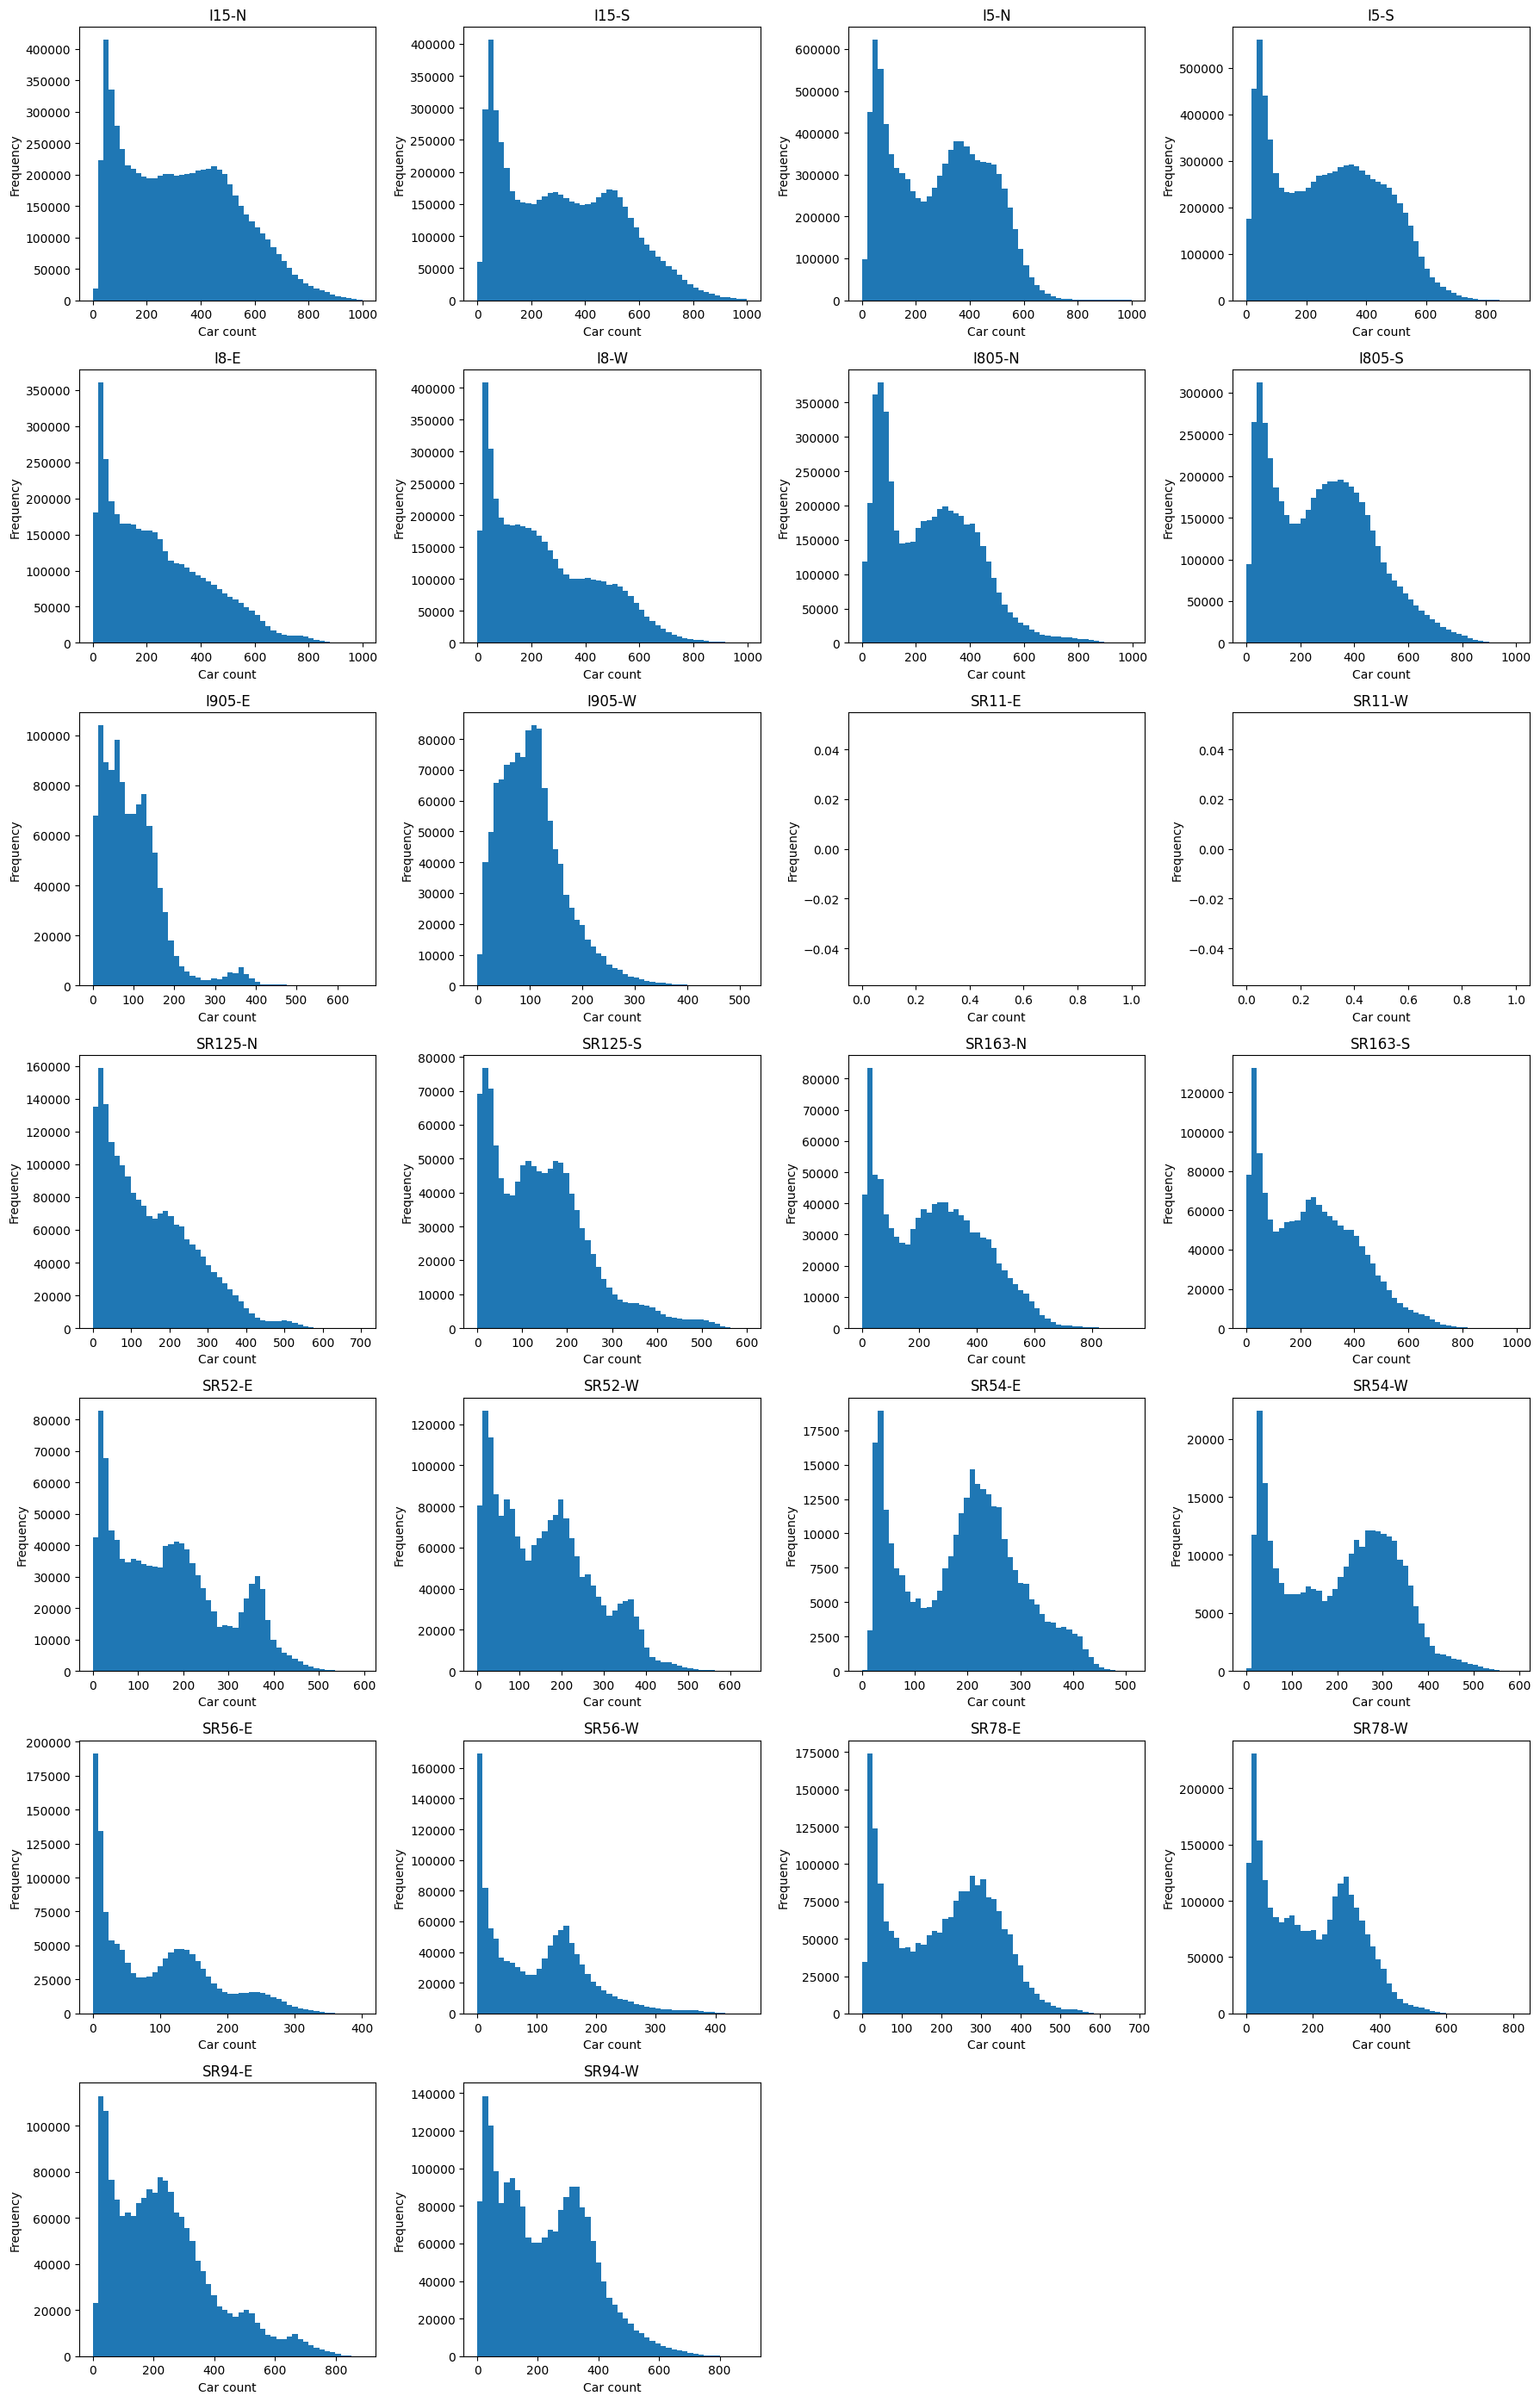

In [92]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# normalize IDs
df_2017.columns = (
    pd.Index(df_2017.columns)
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

meta_df = meta_df.copy()
meta_df["ID"] = (
    meta_df["ID"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# keep only sensors present in both
meta_sub = meta_df[meta_df["ID"].isin(df_2017.columns)].copy()

# sensor -> Fwy mapping
id_to_fwy = meta_sub.set_index("ID")["Fwy"]

# keep aligned columns only
common_ids = df_2017.columns.intersection(id_to_fwy.index)
df_sub = df_2017[common_ids]

# unique freeway-direction labels, e.g. I5-N, I10-E, I405-S
fwy_labels = sorted(id_to_fwy.loc[common_ids].dropna().unique())

print("Unique Fwy groups:", len(fwy_labels))

n = len(fwy_labels)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for ax, fwy in zip(axes, fwy_labels):
    sensor_ids = id_to_fwy[id_to_fwy == fwy].index.intersection(df_sub.columns)

    values = pd.Series(df_sub[sensor_ids].to_numpy().ravel()).dropna()

    ax.hist(values, bins=50)
    ax.set_title(str(fwy))
    ax.set_xlabel("Car count")
    ax.set_ylabel("Frequency")

# hide unused subplot axes
for ax in axes[len(fwy_labels):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

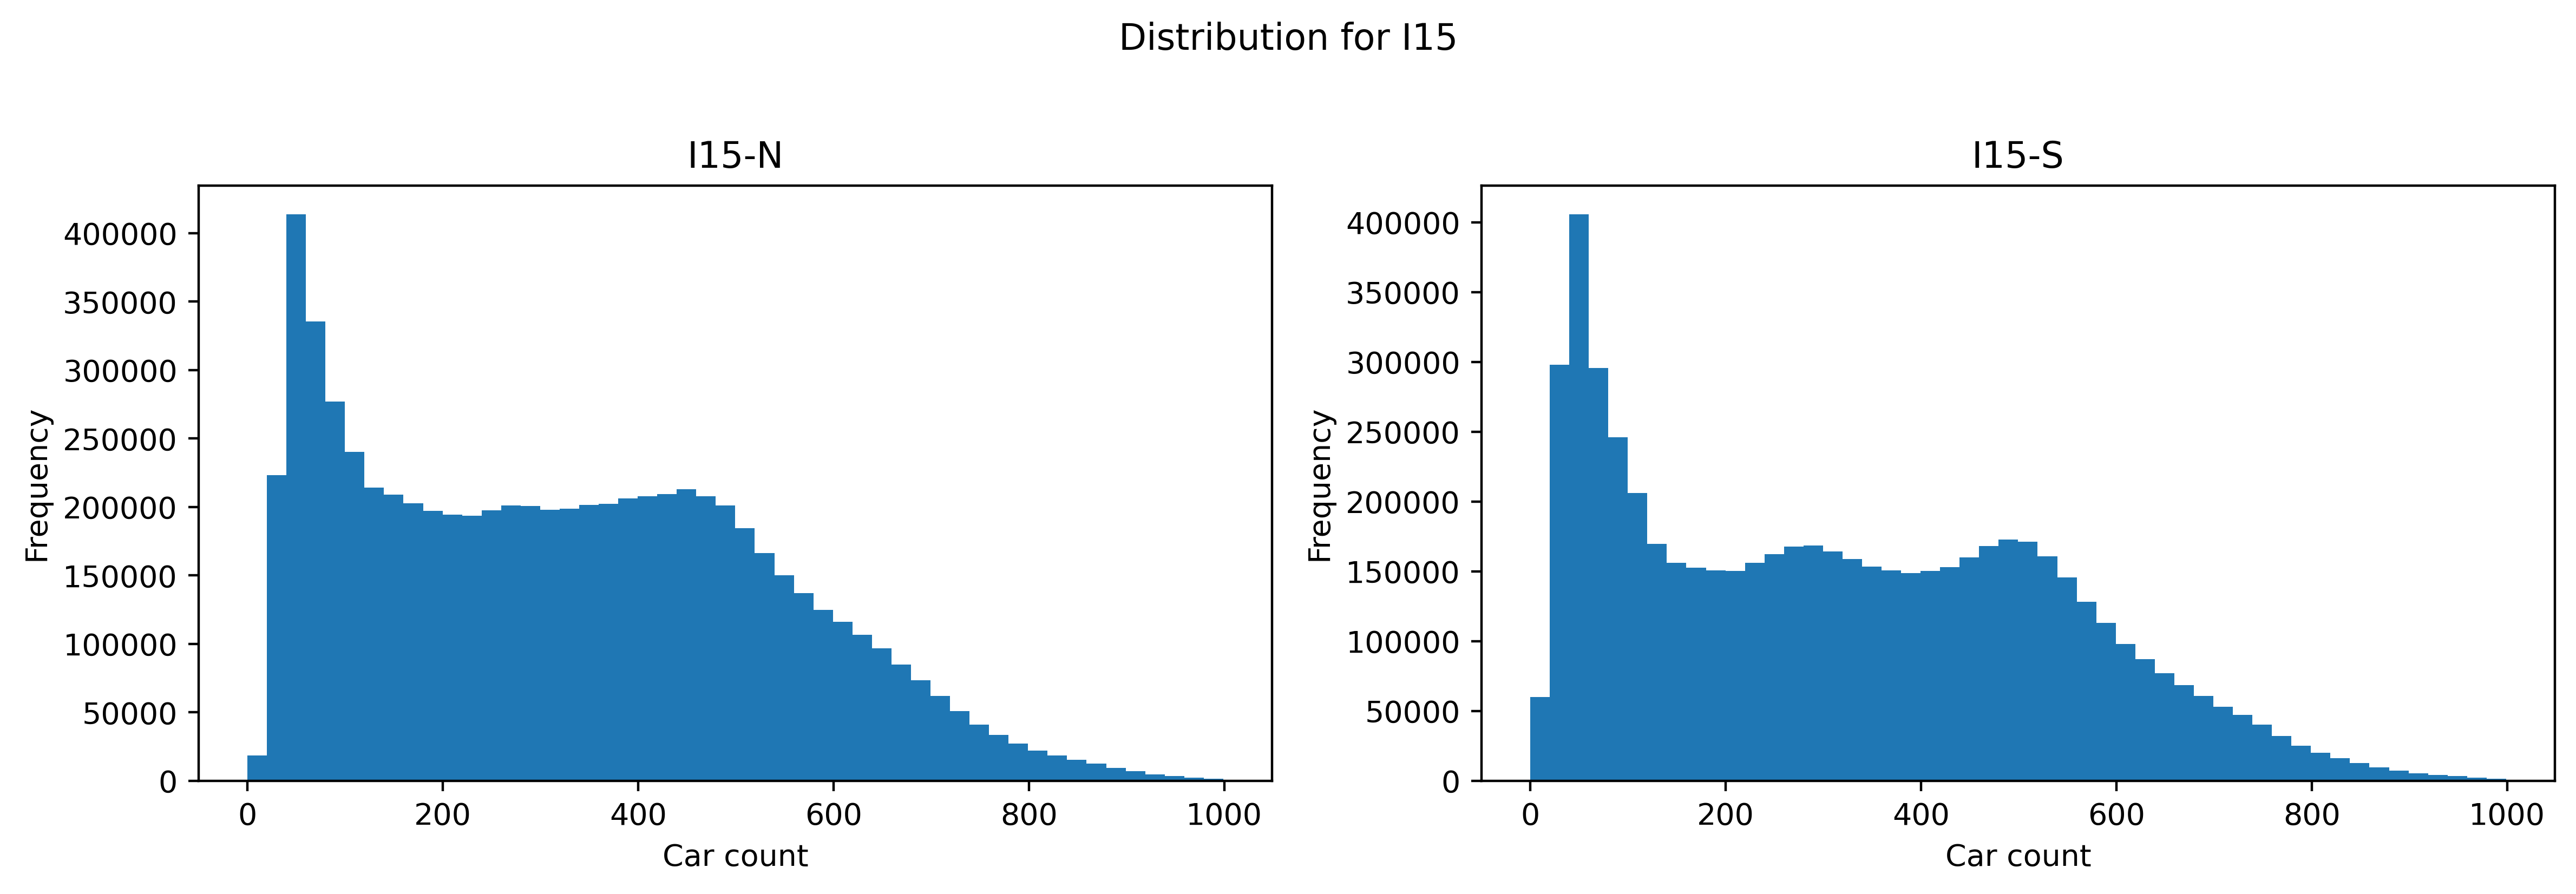

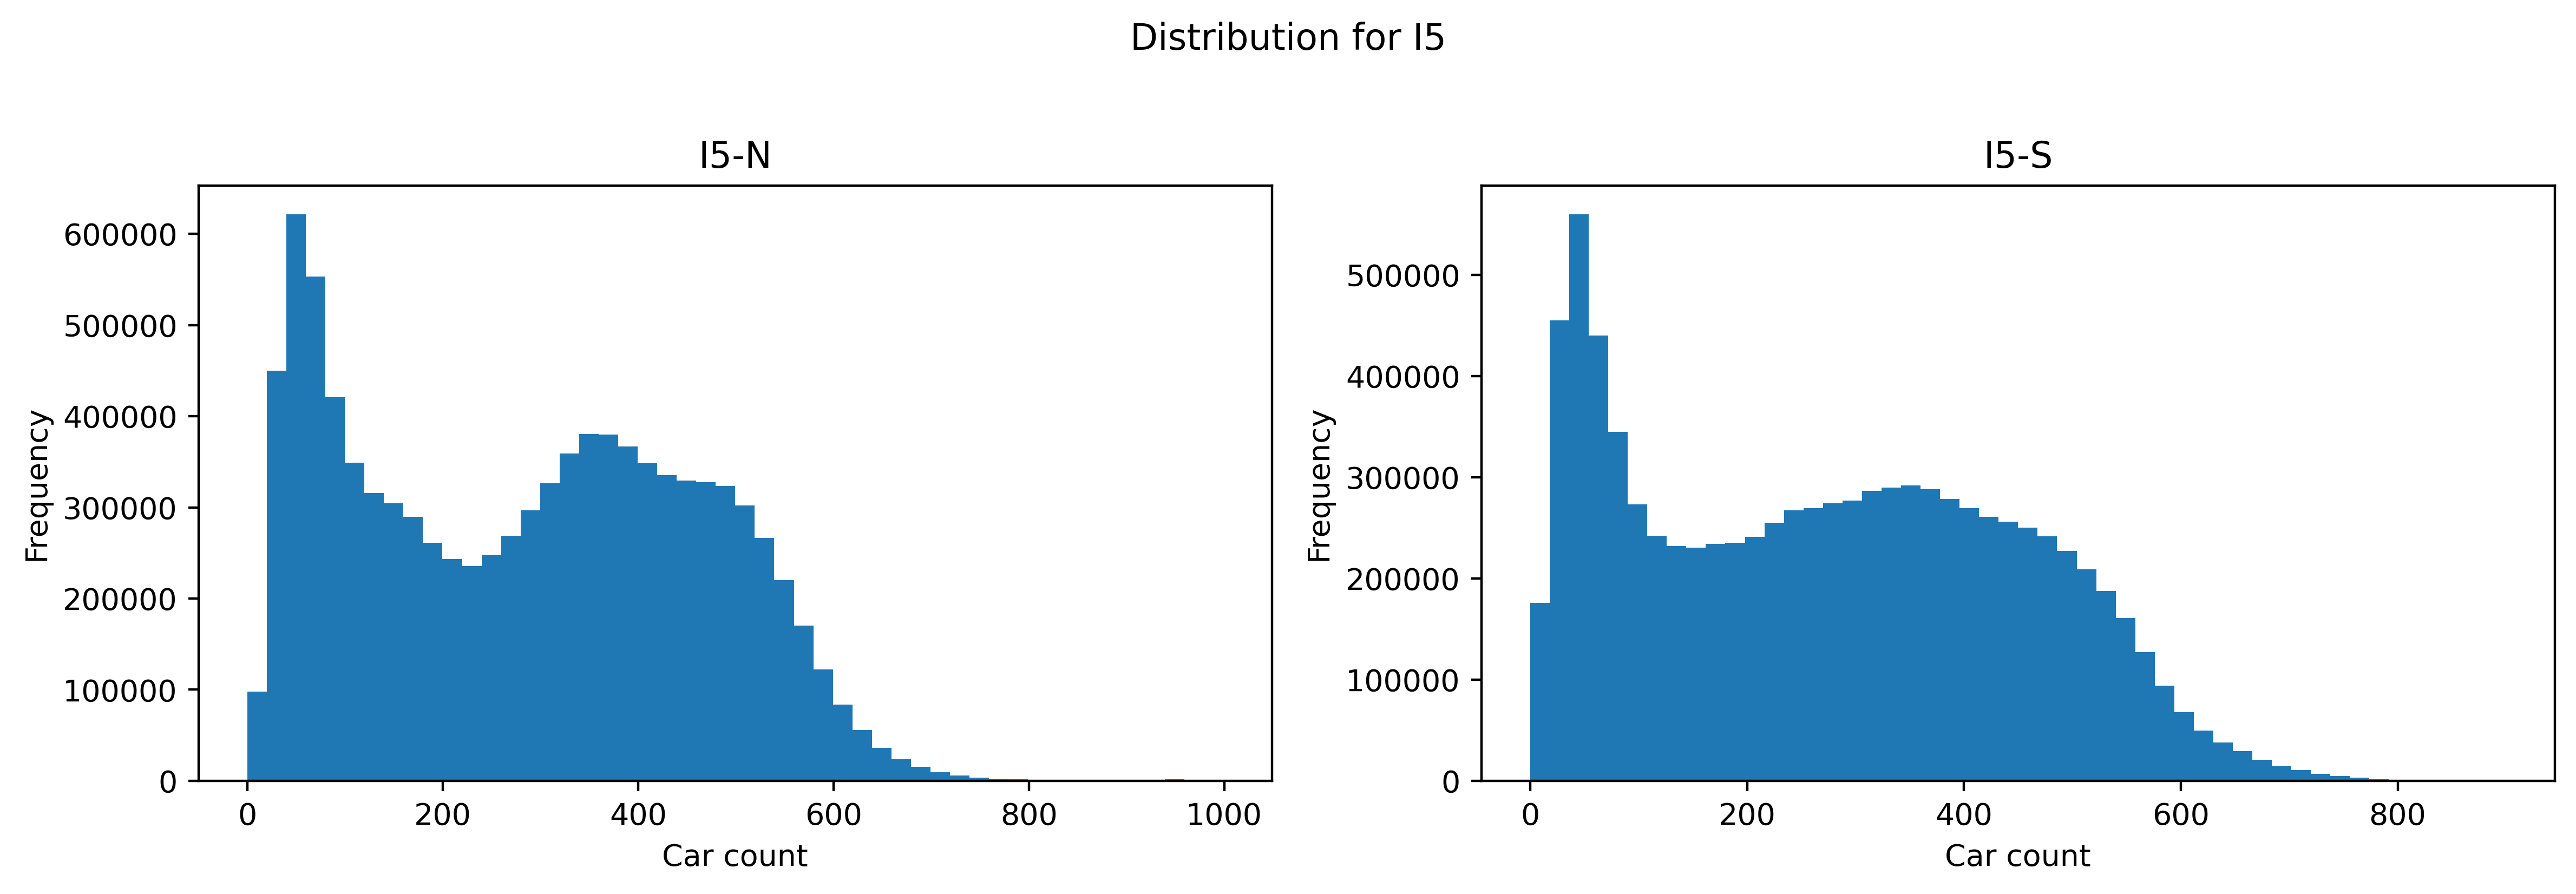

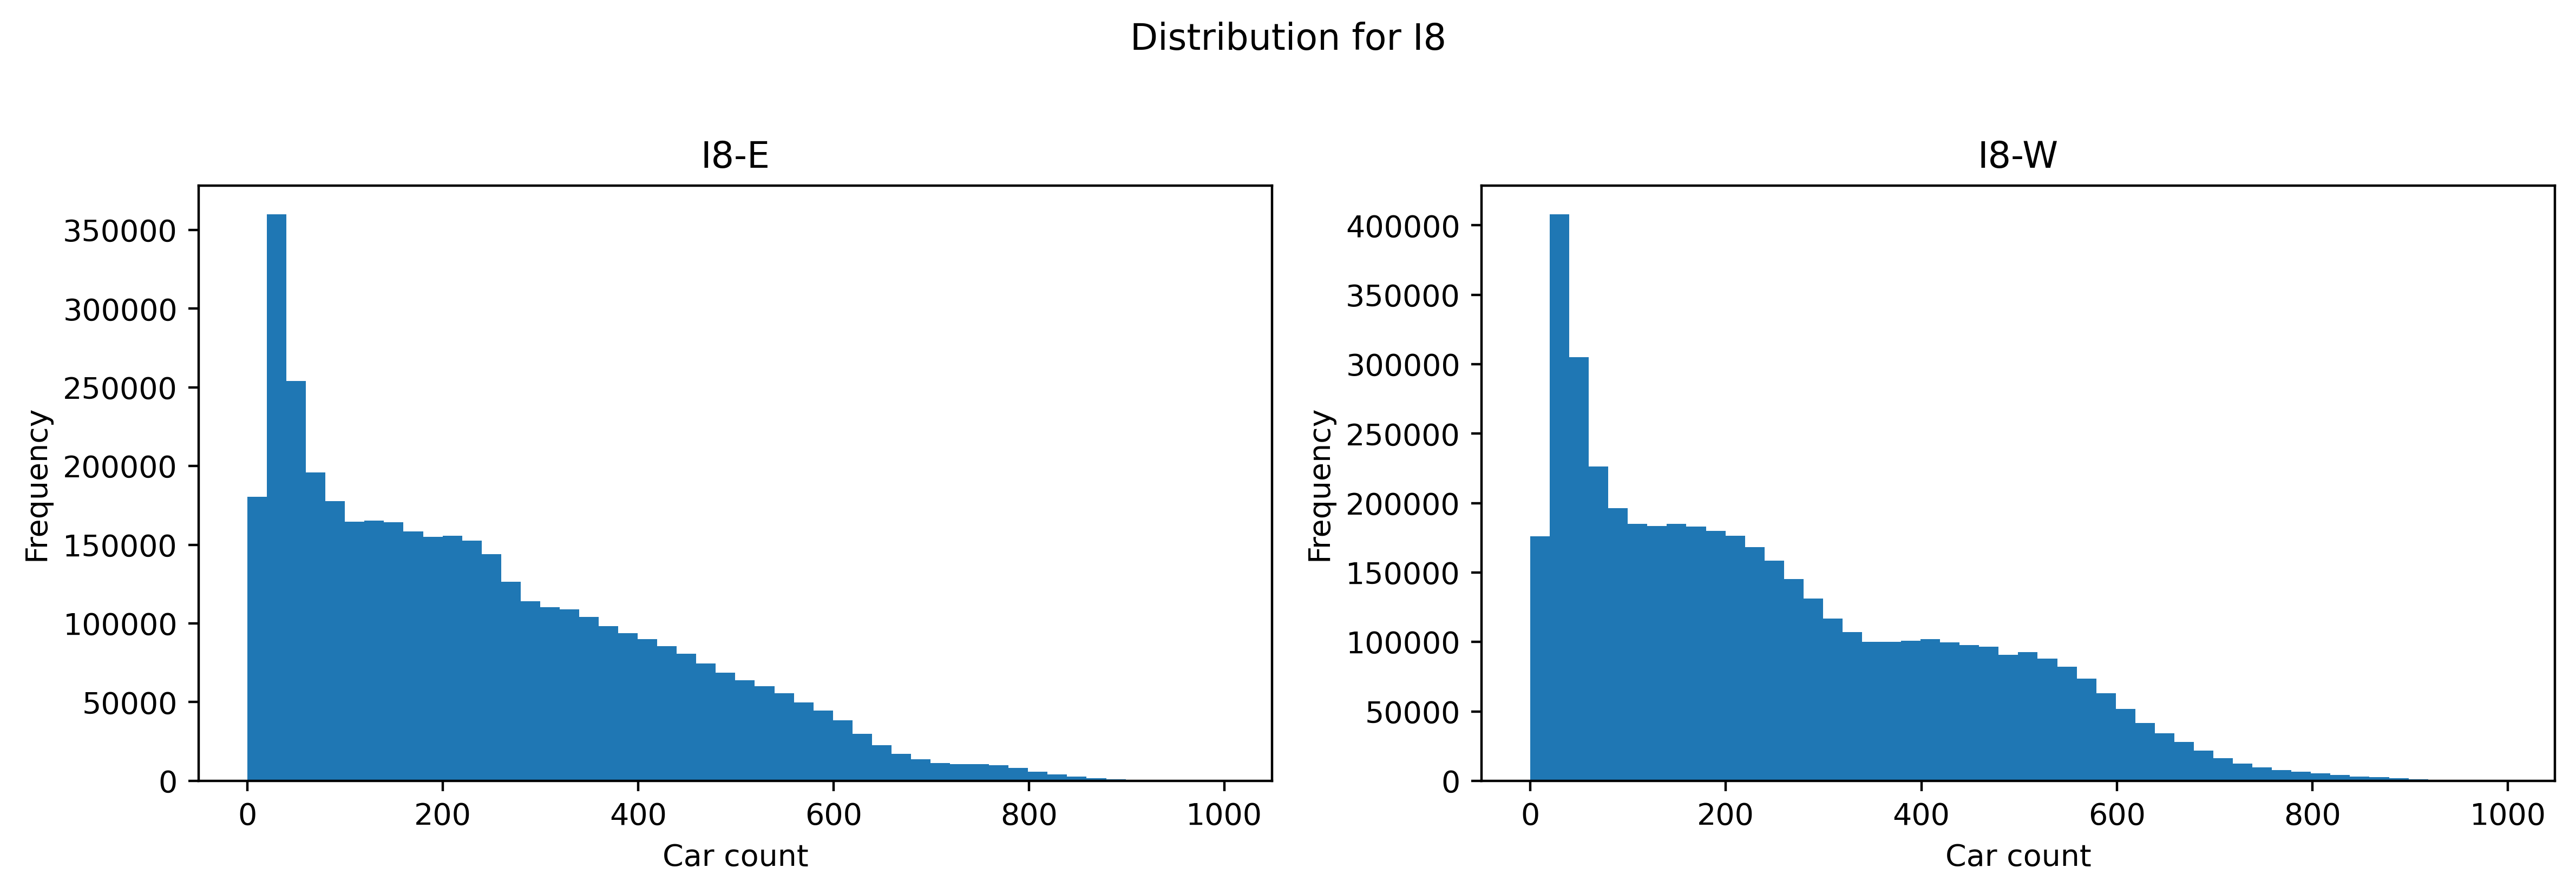

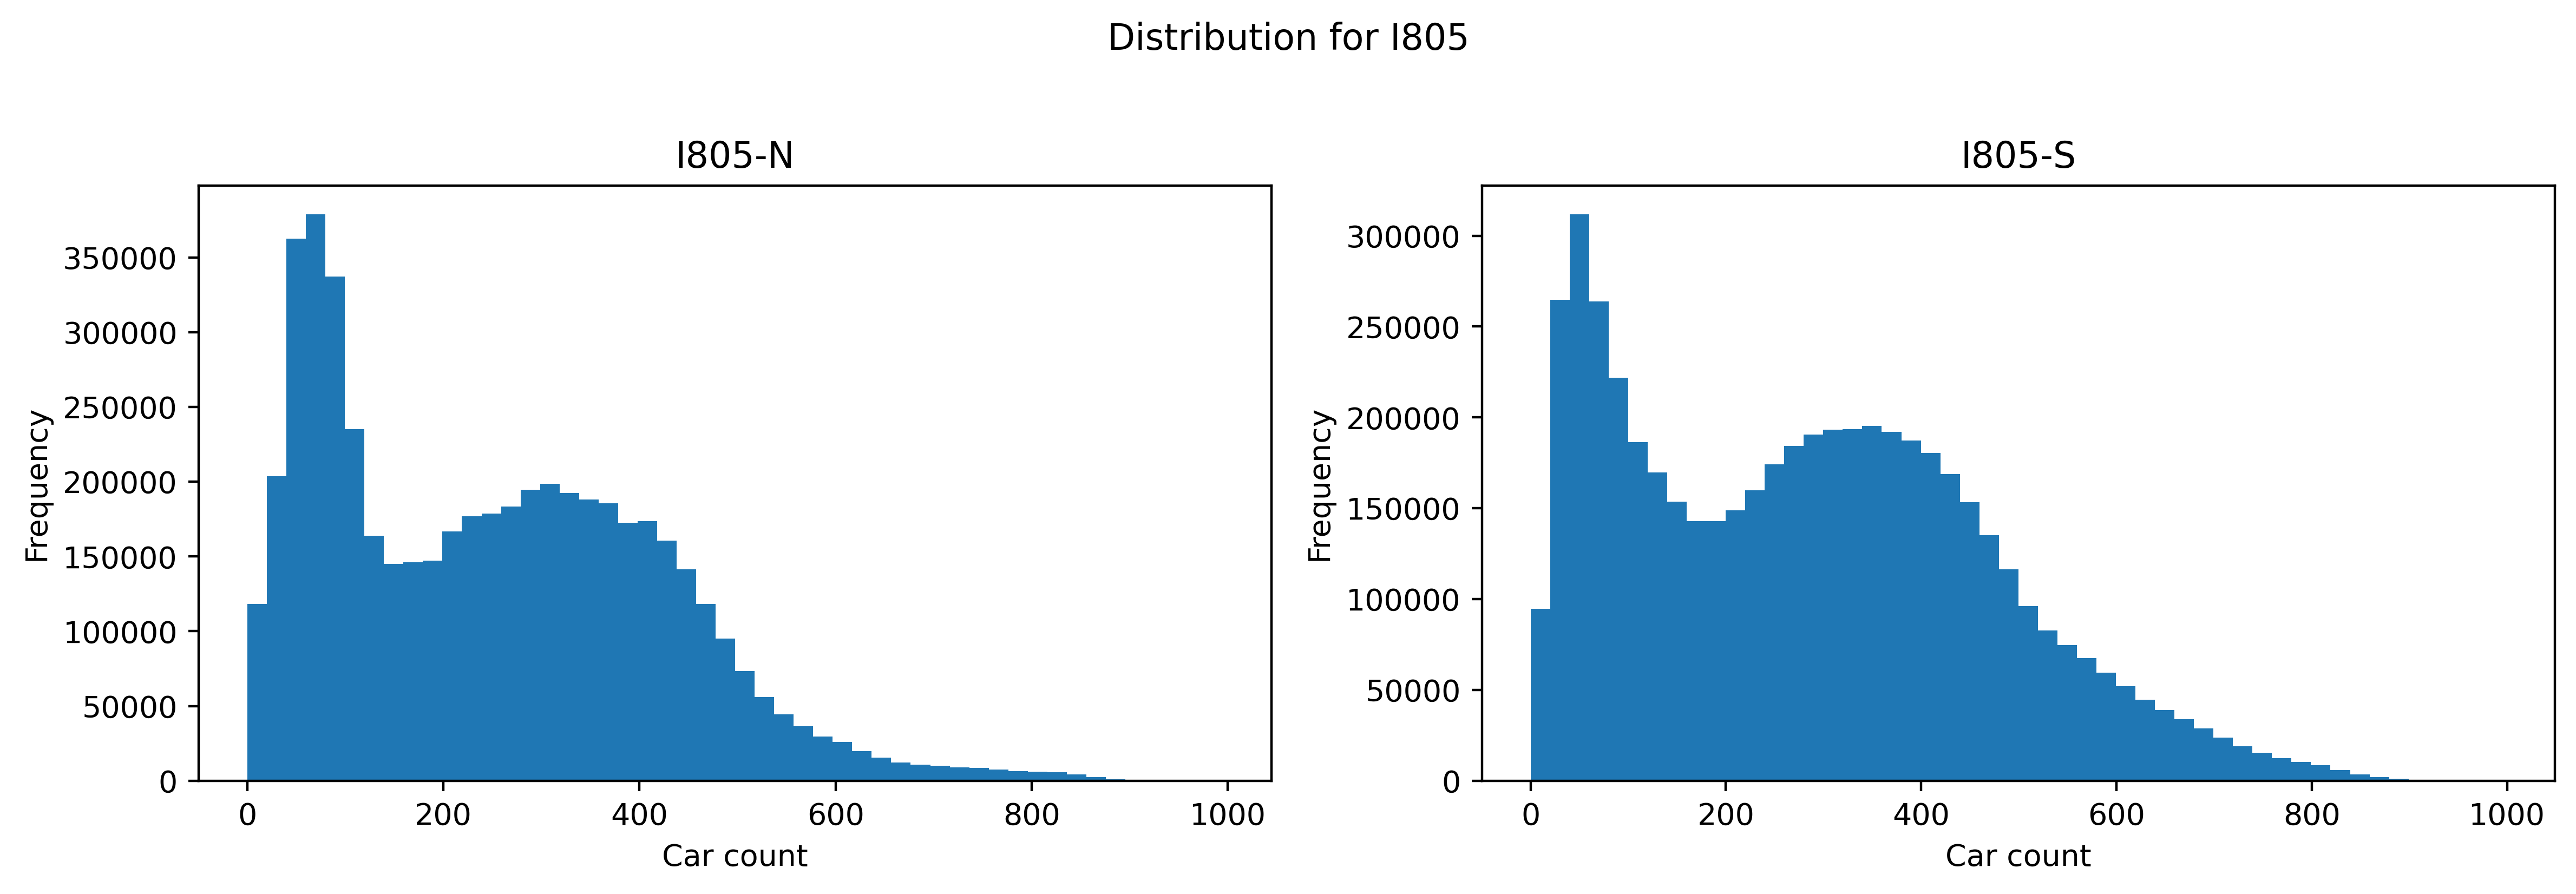

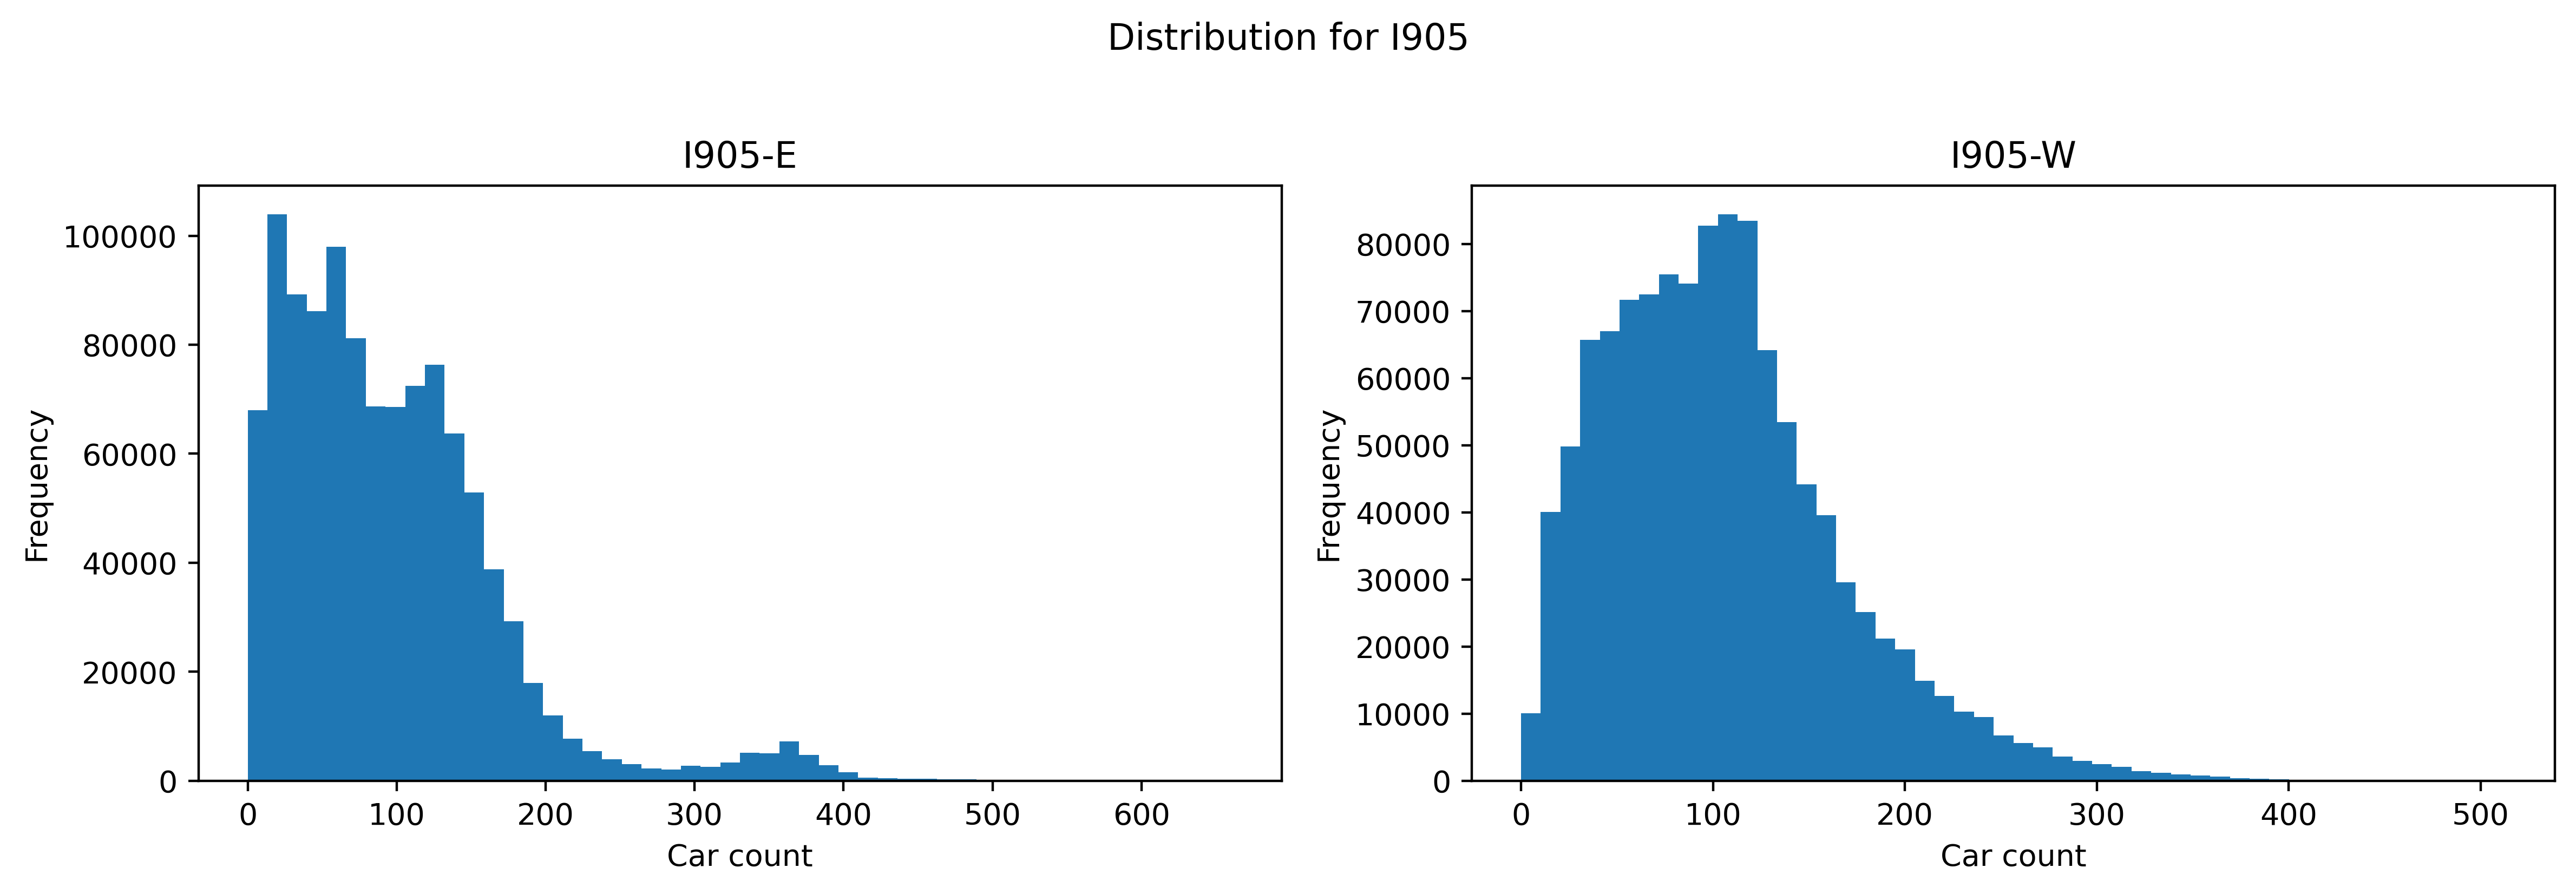

In [99]:
import math
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- normalize IDs ---
df_2017 = df_2017.copy()
meta_df = meta_df.copy()

df_2017.columns = (
    pd.Index(df_2017.columns)
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

meta_df["ID"] = (
    meta_df["ID"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

meta_df["Fwy"] = meta_df["Fwy"].astype(str).str.strip()

# --- keep only matching sensors ---
meta_sub = meta_df[meta_df["ID"].isin(df_2017.columns)].copy()
id_to_fwy = meta_sub.set_index("ID")["Fwy"]

common_ids = df_2017.columns.intersection(id_to_fwy.index)
df_sub = df_2017[common_ids]

# --- parse freeway base, e.g. I15 from I15-N ---
meta_sub["FwyBase"] = meta_sub["Fwy"].str.extract(r"^(I\d+)", expand=False)

# fallback in case pattern is slightly different
meta_sub = meta_sub.dropna(subset=["FwyBase"])

# sensor -> full fwy label and sensor -> fwy base
id_to_fwy_full = meta_sub.set_index("ID")["Fwy"]
id_to_fwy_base = meta_sub.set_index("ID")["FwyBase"]

# --- one figure per freeway base ---
for fwy_base in sorted(meta_sub["FwyBase"].unique()):
    sensor_ids_base = id_to_fwy_base[id_to_fwy_base == fwy_base].index.intersection(df_sub.columns)

    # all full labels inside this freeway, e.g. ['I15-N', 'I15-S']
    direction_groups = sorted(id_to_fwy_full.loc[sensor_ids_base].dropna().unique())

    n = len(direction_groups)
    ncols = min(3, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), dpi=400)
    if n == 1:
        axes = [axes]
    else:
        axes = pd.Index(axes.ravel() if hasattr(axes, "ravel") else axes)

    for ax, fwy_full in zip(axes, direction_groups):
        sensor_ids = id_to_fwy_full[id_to_fwy_full == fwy_full].index.intersection(df_sub.columns)

        values = pd.Series(df_sub[sensor_ids].to_numpy().ravel()).dropna()

        ax.hist(values, bins=50)
        ax.set_title(fwy_full)
        ax.set_xlabel("Car count")
        ax.set_ylabel("Frequency")

    # hide unused axes
    for ax in axes[len(direction_groups):]:
        ax.axis("off")

    fig.suptitle(f"Distribution for {fwy_base}", y=1.02)
    plt.tight_layout()
    plt.show()

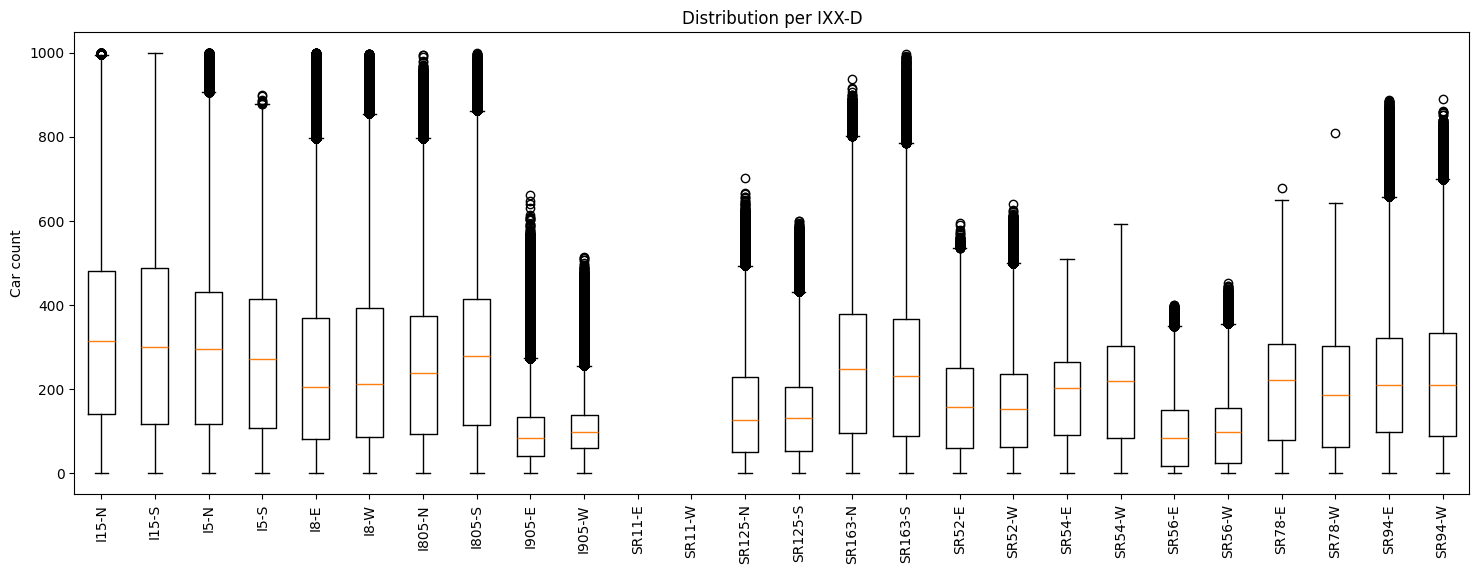

In [95]:
data = {
    fwy: pd.Series(df_sub[id_to_fwy[id_to_fwy == fwy].index].to_numpy().ravel()).dropna()
    for fwy in fwy_groups
}

plt.figure(figsize=(18,6))
plt.boxplot(data.values(), tick_labels=data.keys())
plt.xticks(rotation=90)
plt.ylabel("Car count")
plt.title("Distribution per IXX-D")
plt.show()

In [100]:
df = df_2017.copy()
meta = meta_df.copy()

df.columns = (
    pd.Index(df.columns)
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

meta["ID"] = (
    meta["ID"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

meta["Fwy"] = meta["Fwy"].astype(str).str.strip()
meta["Lanes"] = pd.to_numeric(meta["Lanes"], errors="coerce")

meta = meta[meta["ID"].isin(df.columns)].copy()
meta = meta.dropna(subset=["Fwy", "Lanes"])
meta = meta.set_index("ID")

common_ids = df.columns.intersection(meta.index)
df = df[common_ids]
meta = meta.loc[common_ids]

In [101]:
fwy_target = "I15-N"

sensor_ids = meta.index[meta["Fwy"] == fwy_target]
df_sub = df[sensor_ids]

weights = meta.loc[sensor_ids, "Lanes"]

collapsed_I15N = df_sub.mul(weights, axis=1).sum(axis=1) / weights.sum()

In [102]:
collapsed = pd.DataFrame(index=df.index)

for fwy, ids in meta.groupby("Fwy").groups.items():
    ids = list(ids)
    weights = meta.loc[ids, "Lanes"]
    collapsed[fwy] = df[ids].mul(weights, axis=1).sum(axis=1) / weights.sum()

In [103]:
collapsed

,I15-N,I15-S,I5-N,I5-S,I8-E,I8-W,I805-N,I805-S,I905-E,I905-W,...,SR52-E,SR52-W,SR54-E,SR54-W,SR56-E,SR56-W,SR78-E,SR78-W,SR94-E,SR94-W
Time,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,68.669617,65.888889,64.550868,68.339726,65.316901,46.755556,46.358209,63.927928,18.411765,24.090909,...,49.621622,63.28,36.666667,51.333333,16.516129,14.695652,40.384615,39.055556,114.880597,57.316456
2017-01-01 00:05:00,65.085546,58.372760,61.354839,68.506849,67.436620,59.822222,45.054726,64.067568,17.000000,26.121212,...,52.918919,62.74,38.333333,29.000000,22.838710,12.173913,37.661538,37.625000,68.313433,44.594937
2017-01-01 00:10:00,70.280236,63.390681,68.498759,74.841096,88.823944,67.722222,53.890547,71.090090,13.294118,25.363636,...,56.378378,67.62,49.666667,38.333333,29.806452,21.565217,54.723077,53.111111,79.447761,60.291139
2017-01-01 00:15:00,85.235988,84.519713,88.009926,84.939726,113.852113,78.788889,75.786070,84.932432,13.176471,23.878788,...,56.864865,70.74,85.000000,79.000000,33.741935,28.695652,71.123077,60.958333,112.343284,82.873418
2017-01-01 00:20:00,110.802360,100.408602,104.672457,91.424658,124.901408,86.438889,92.179104,105.261261,20.705882,19.787879,...,59.945946,78.22,115.000000,102.333333,49.935484,35.565217,88.661538,72.972222,138.776119,102.810127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 23:35:00,108.286136,98.684588,94.975186,101.430137,107.204225,95.450000,81.203980,113.369369,39.764706,40.606061,...,44.891892,39.36,98.000000,69.666667,30.419355,22.347826,62.723077,67.166667,121.955224,90.518987
2017-12-31 23:40:00,102.684366,96.469534,96.816377,92.400000,102.507042,80.666667,79.184080,111.918919,36.323529,44.272727,...,36.891892,34.78,81.333333,65.333333,29.387097,23.217391,60.738462,60.250000,117.641791,82.037975
2017-12-31 23:45:00,93.132743,88.473118,85.662531,88.191781,96.739437,80.316667,73.970149,103.923423,34.617647,38.696970,...,38.567568,32.82,72.000000,71.333333,27.741935,23.347826,51.415385,51.902778,119.507463,81.012658


In [104]:
collapsed_by_lane = pd.DataFrame(index=df.index)

for (fwy, lane), ids in meta.groupby(["Fwy", "Lanes"]).groups.items():
    ids = list(ids)

    # collapse all sensors in the same fwy/lane group
    # plain mean within same lane-count group is usually fine
    collapsed_by_lane[(fwy, lane)] = df[ids].mean(axis=1)

collapsed_by_lane.columns = pd.MultiIndex.from_tuples(
    collapsed_by_lane.columns,
    names=["Fwy", "Lanes"]
)

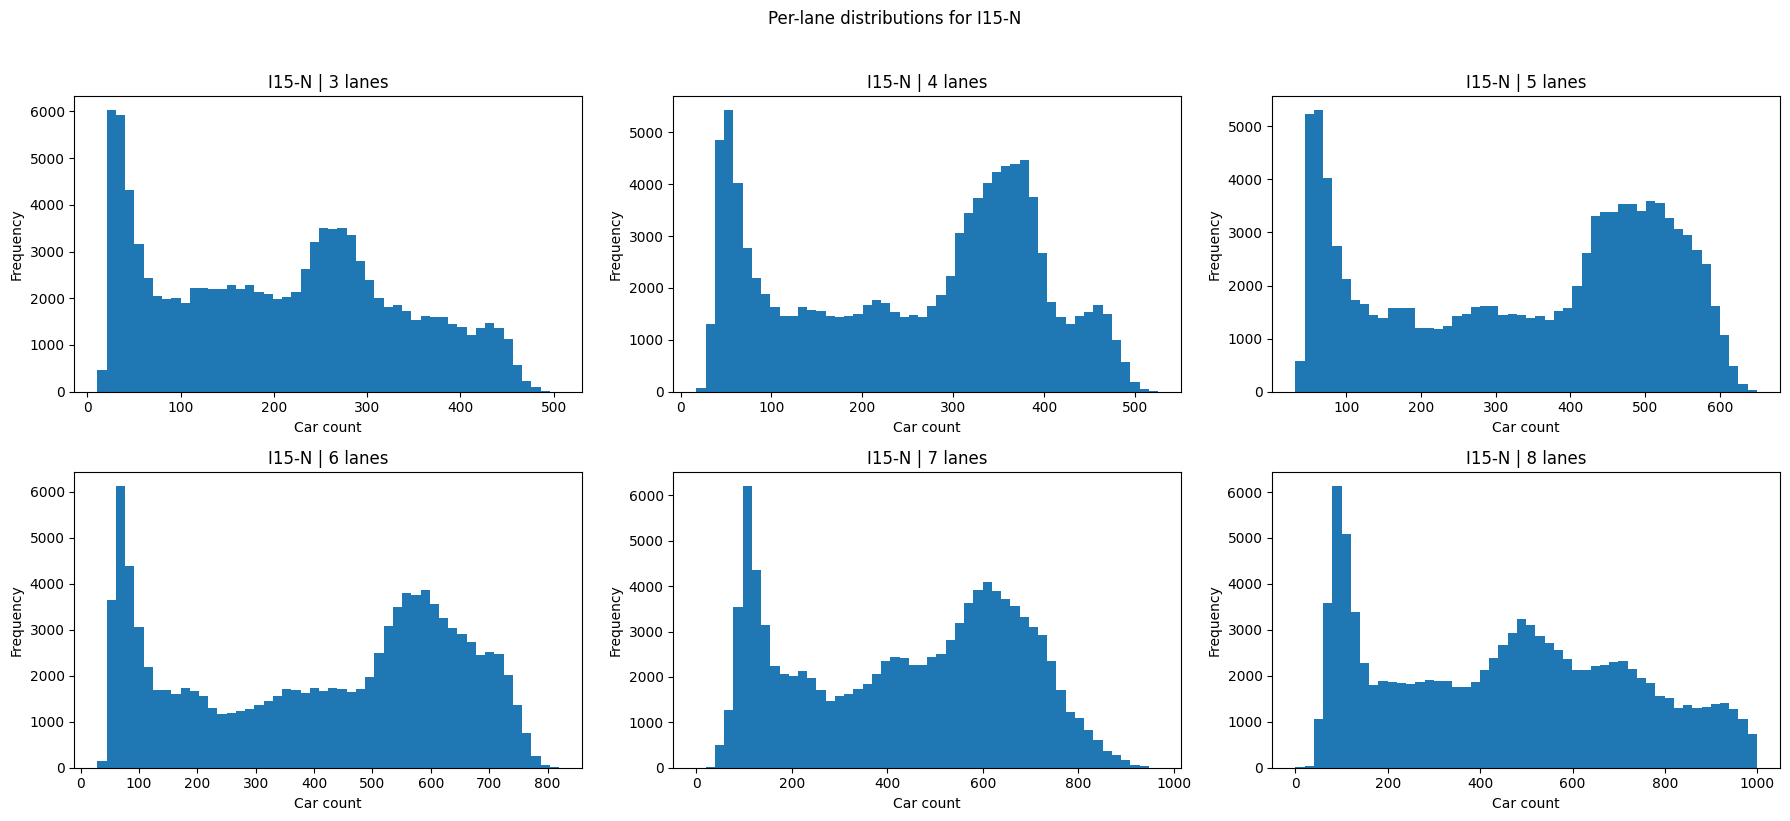

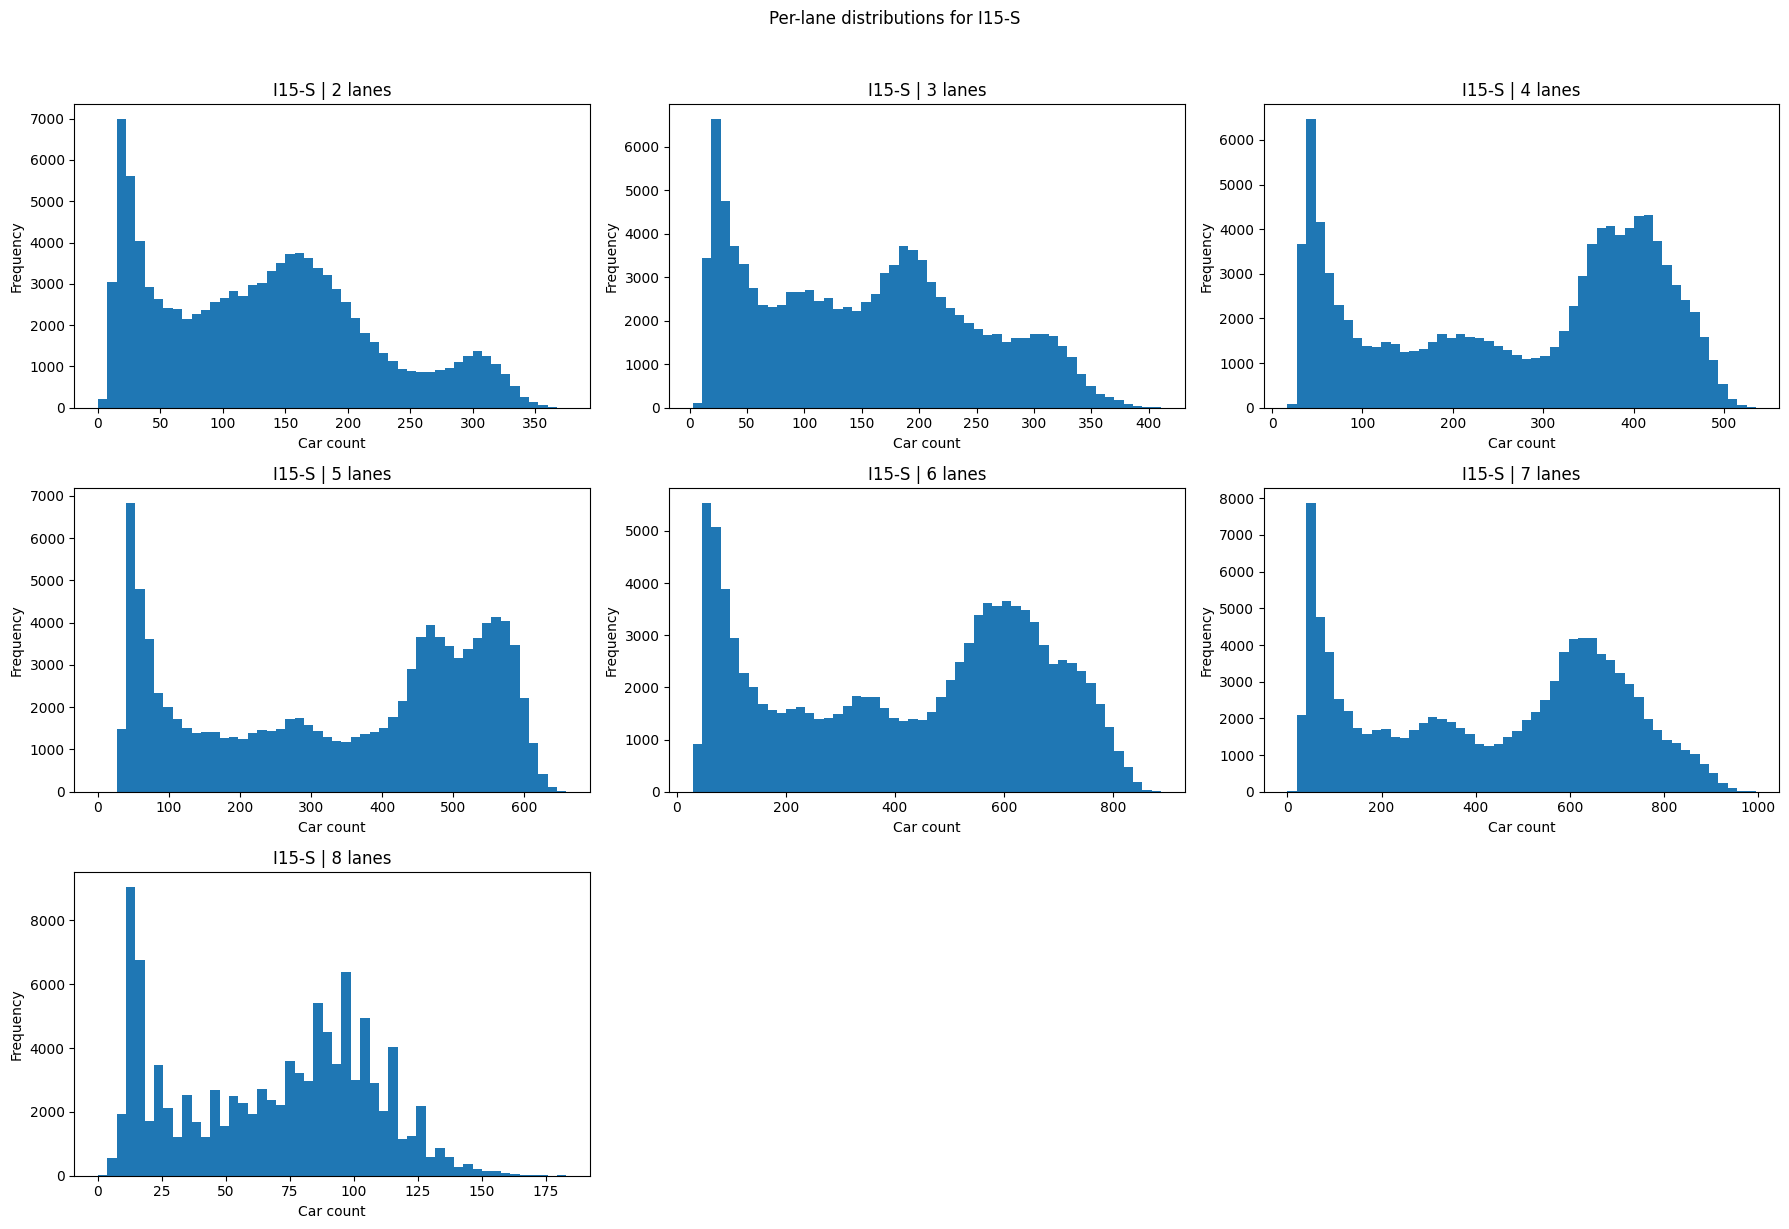

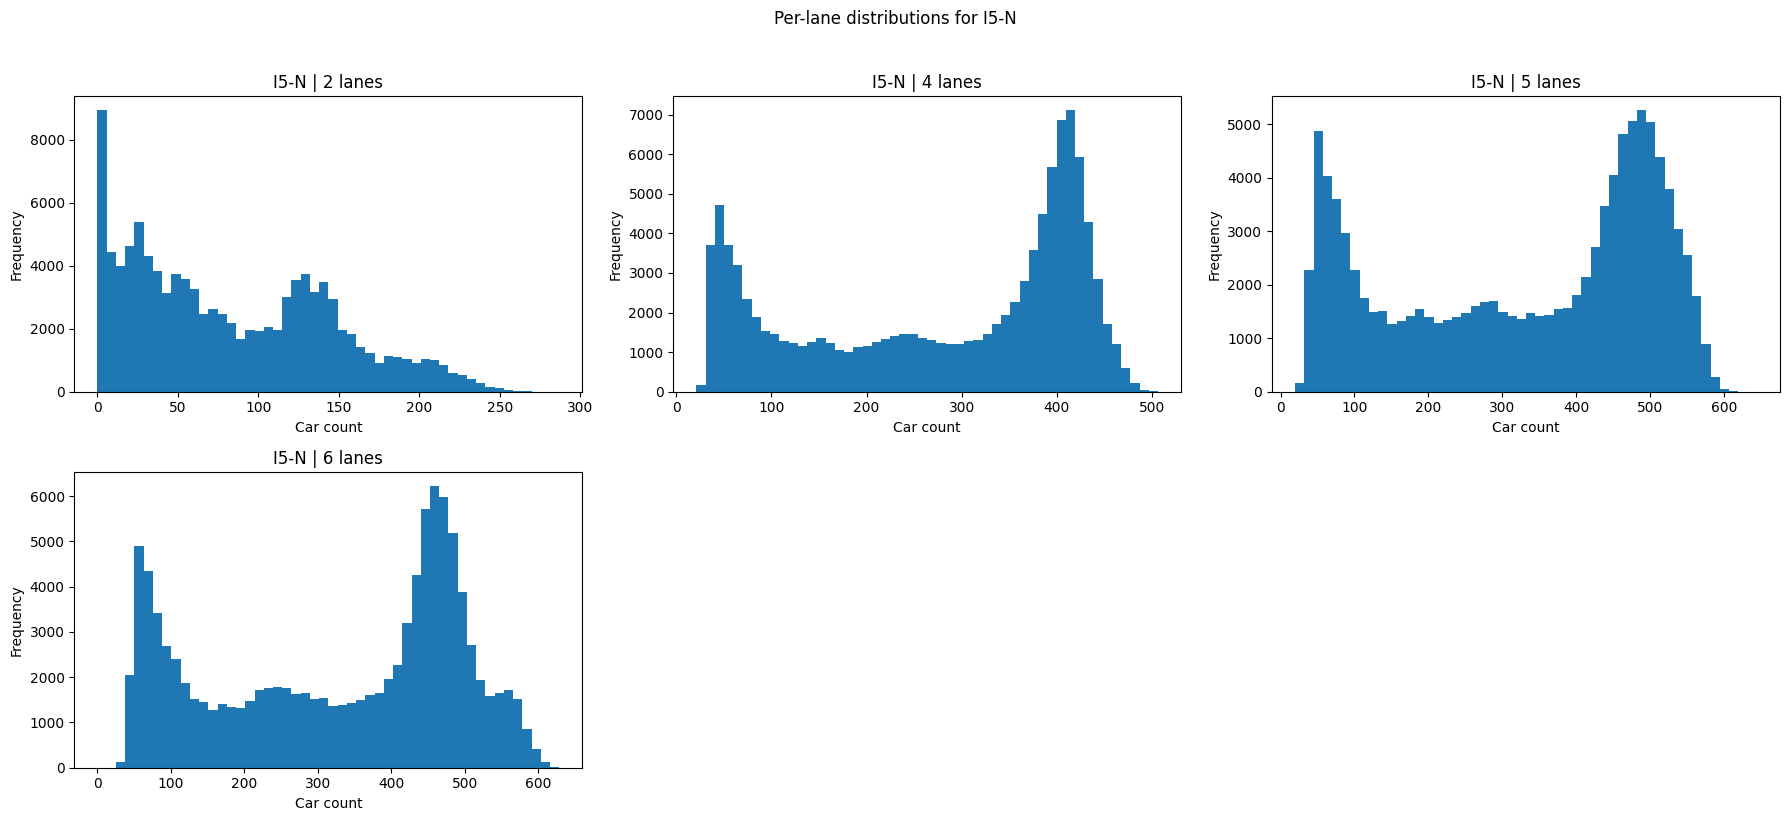

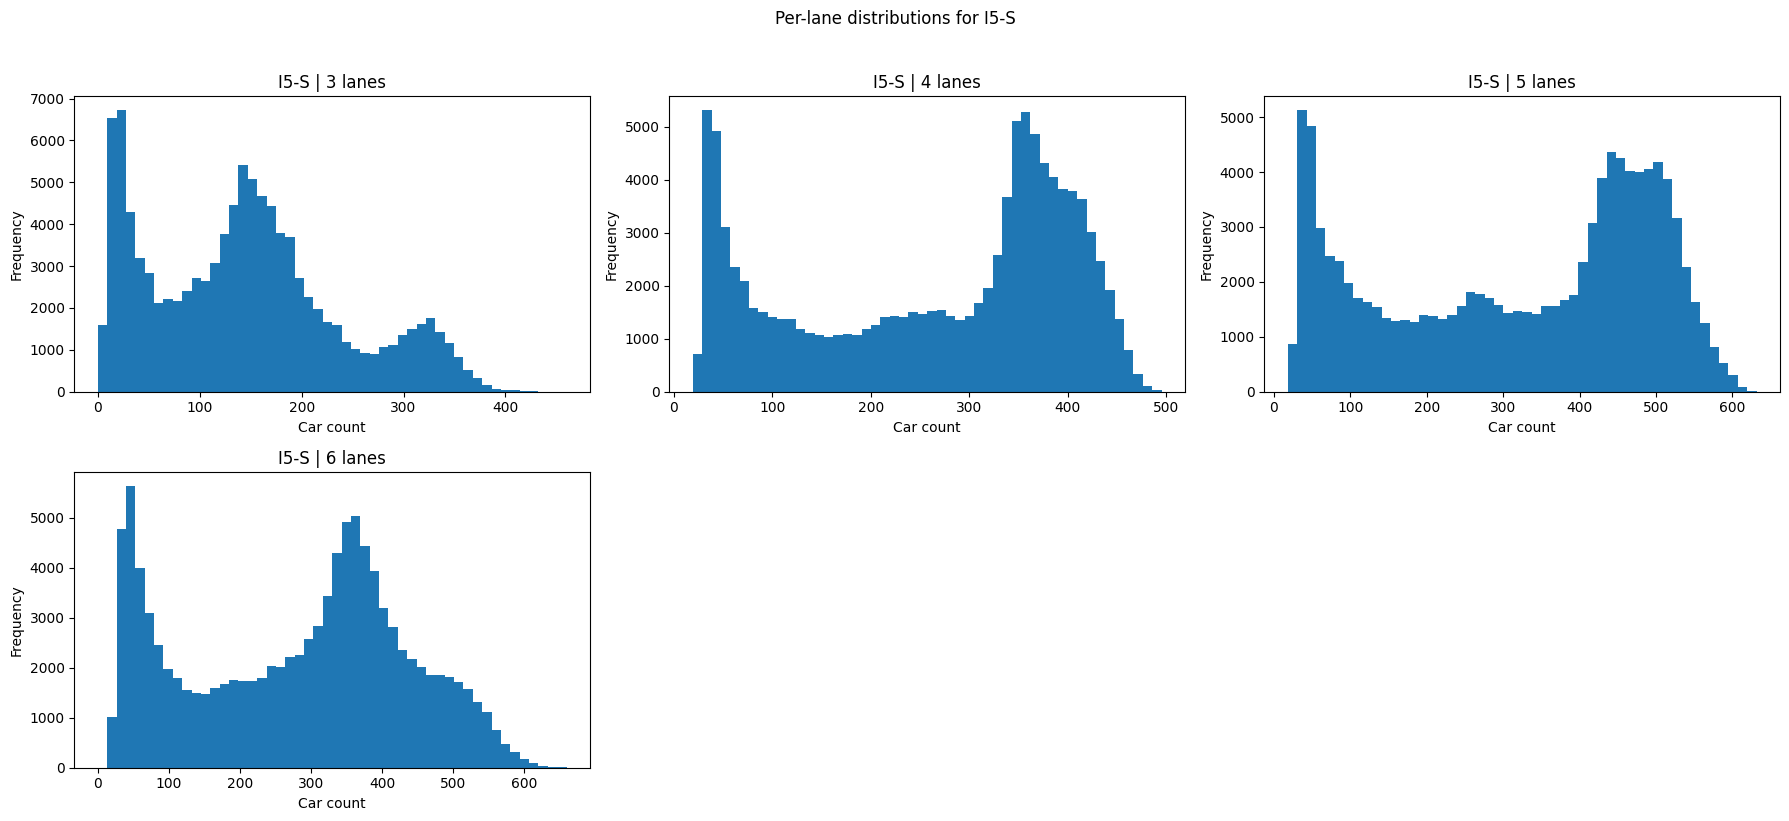

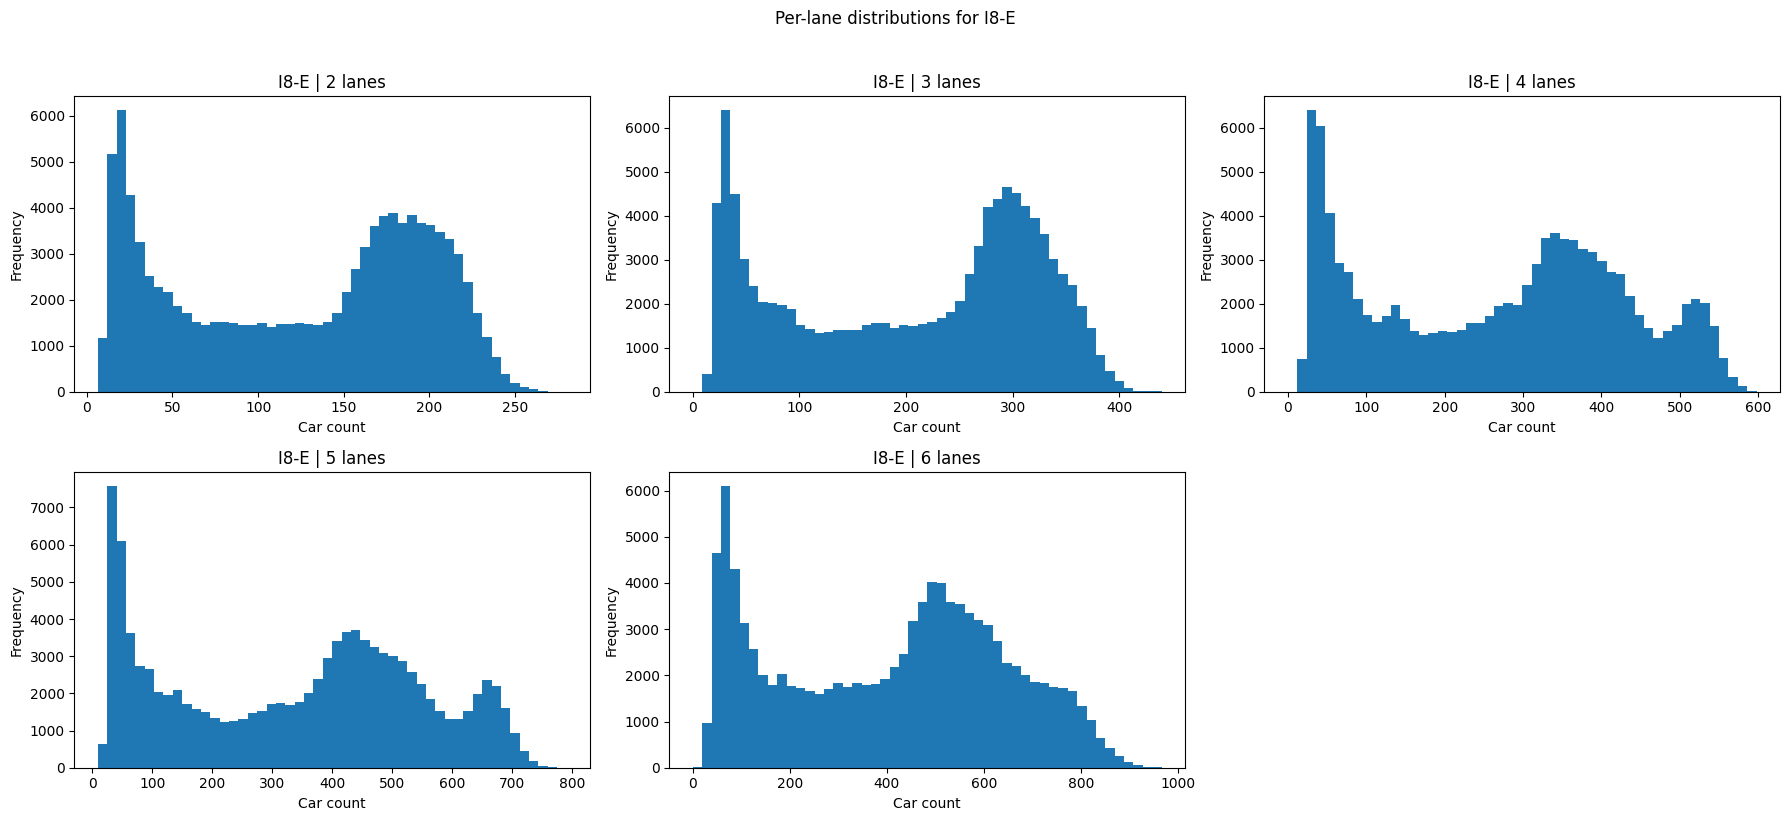

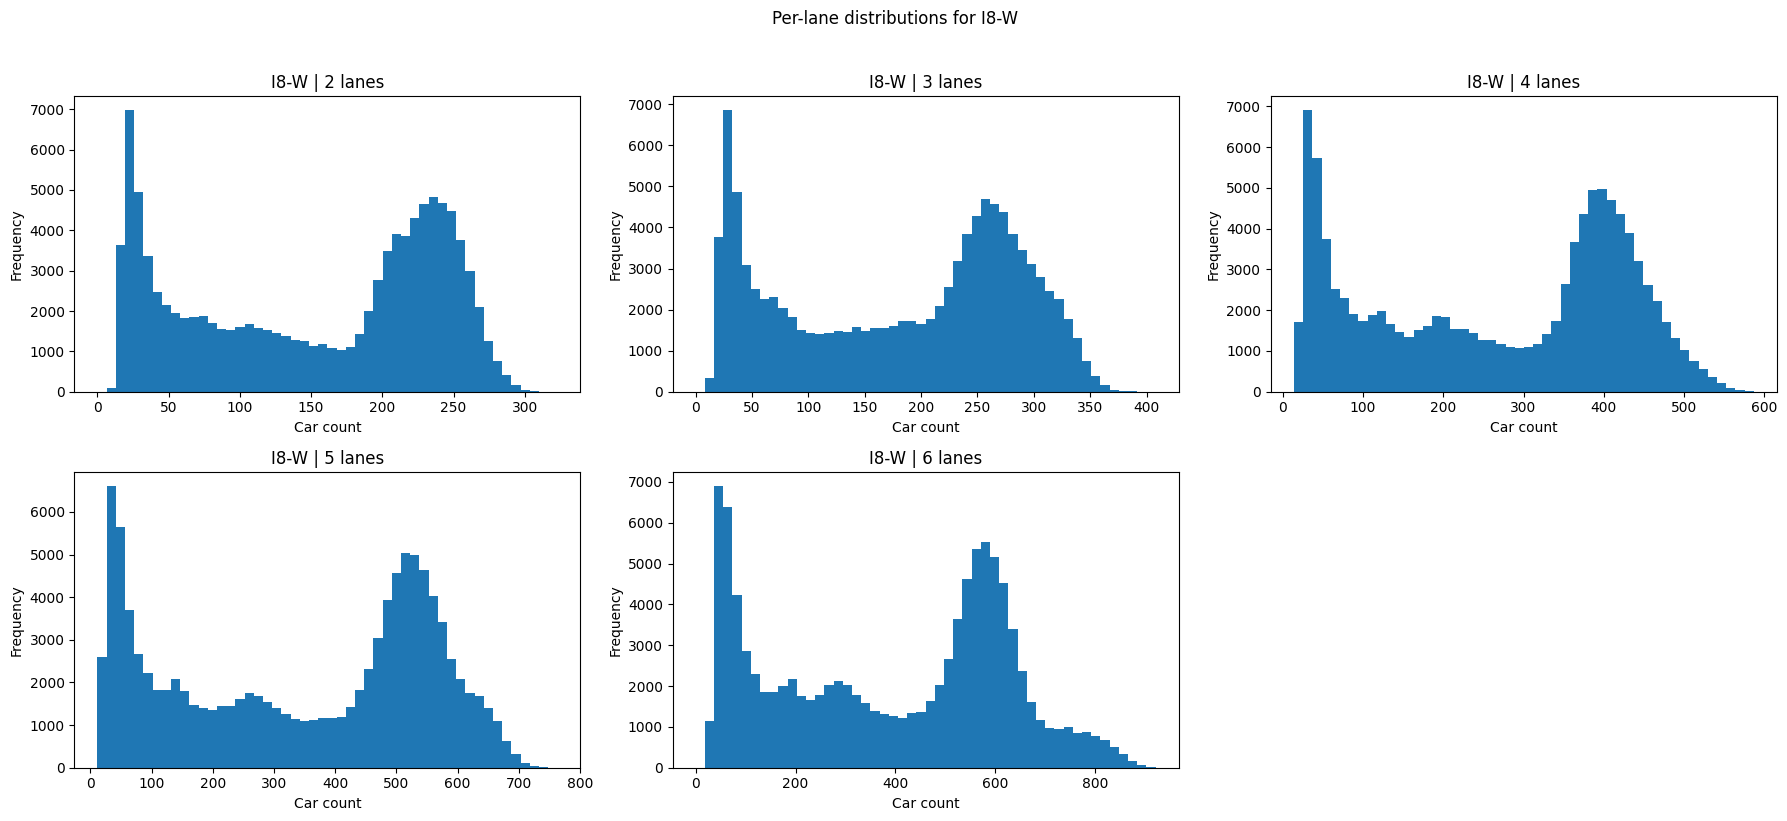

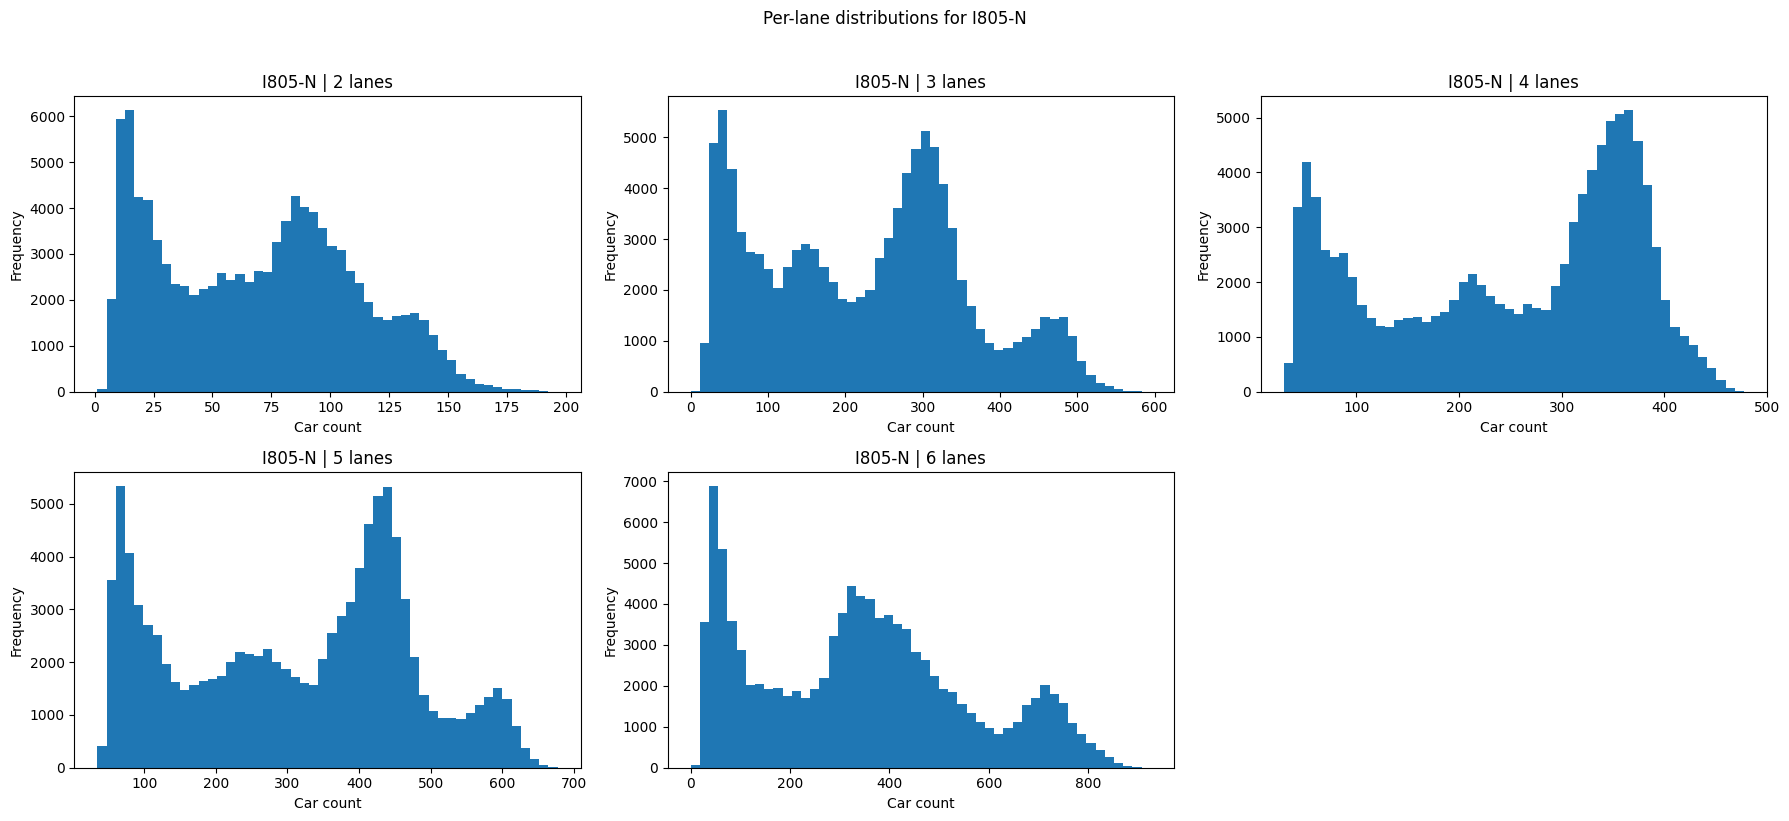

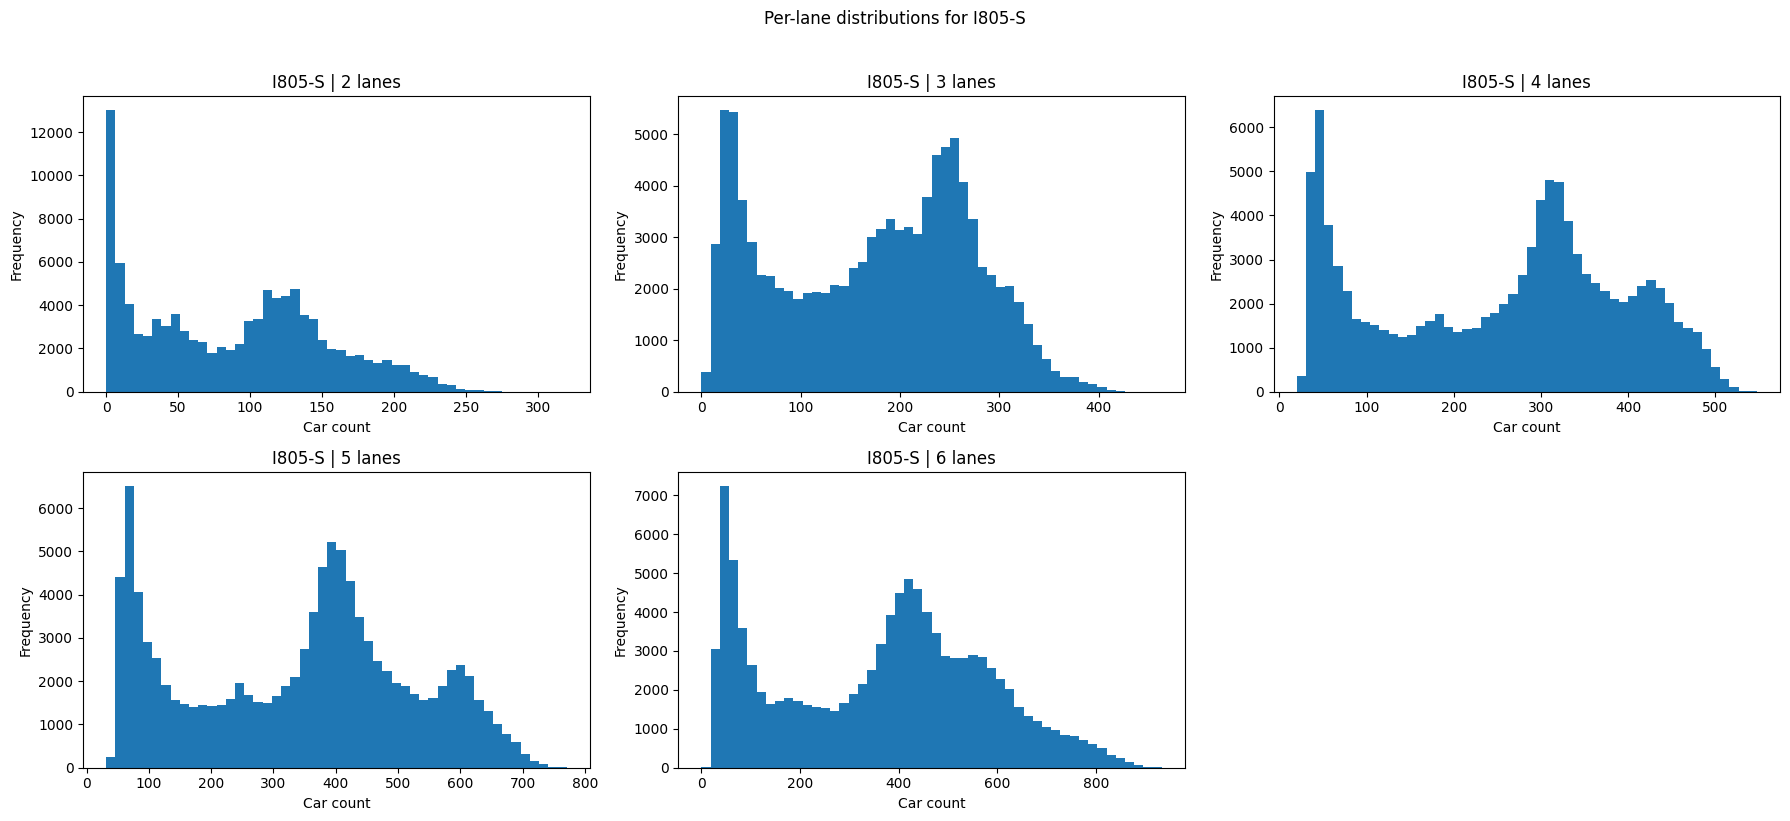

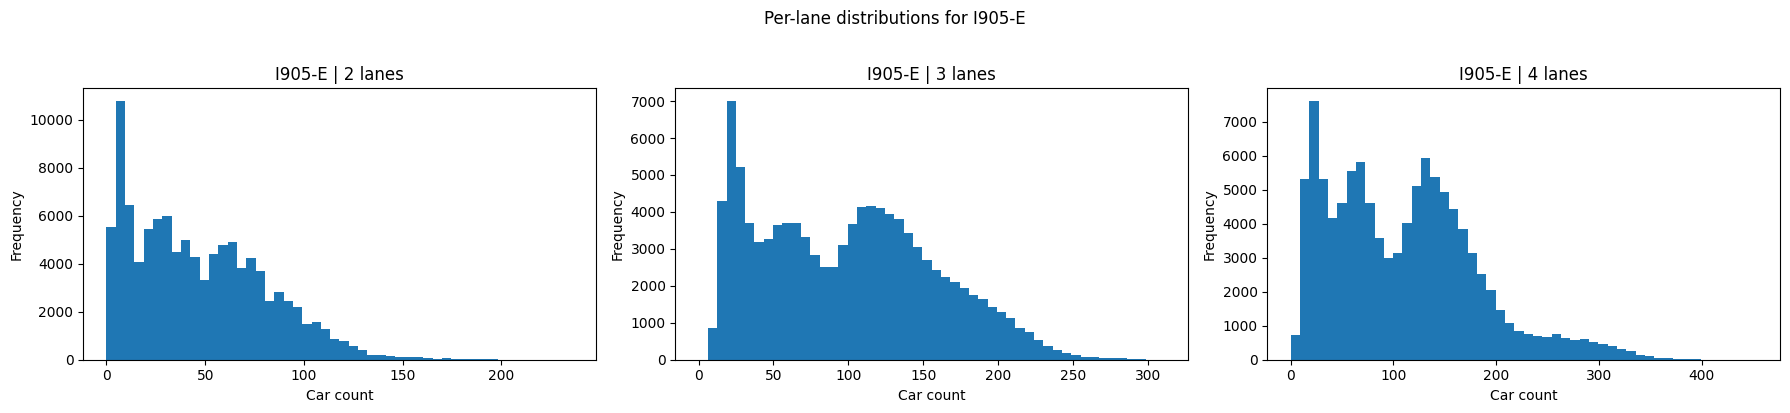

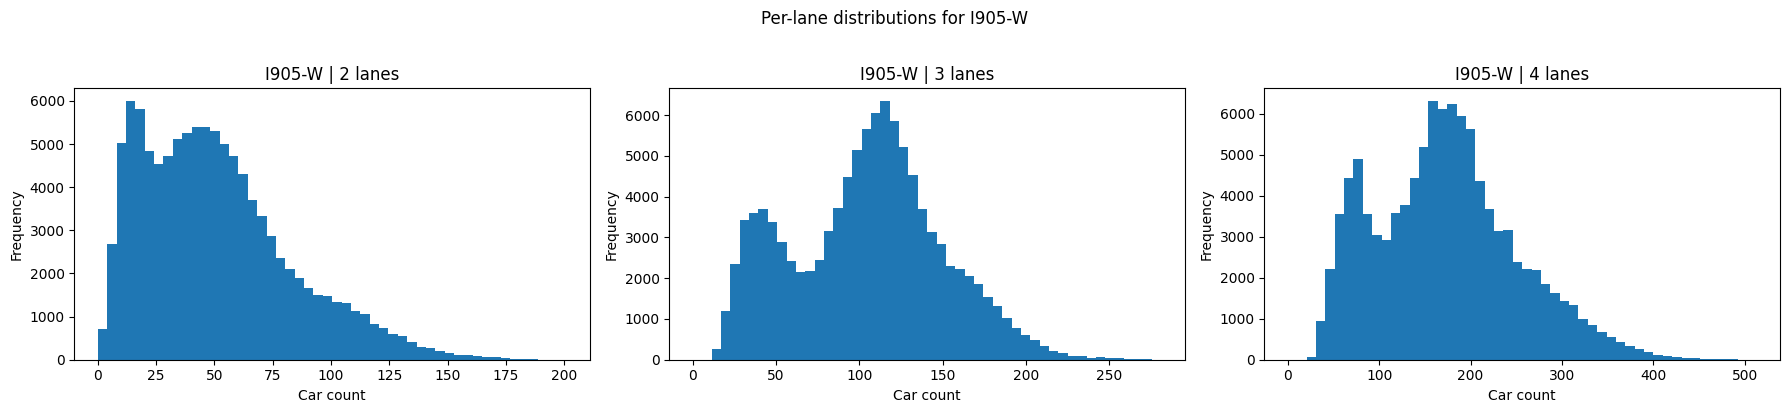

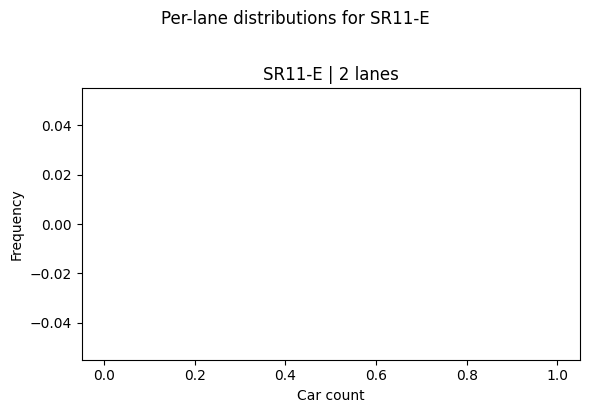

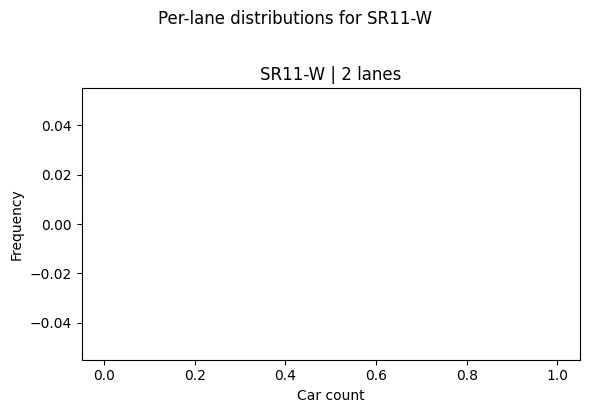

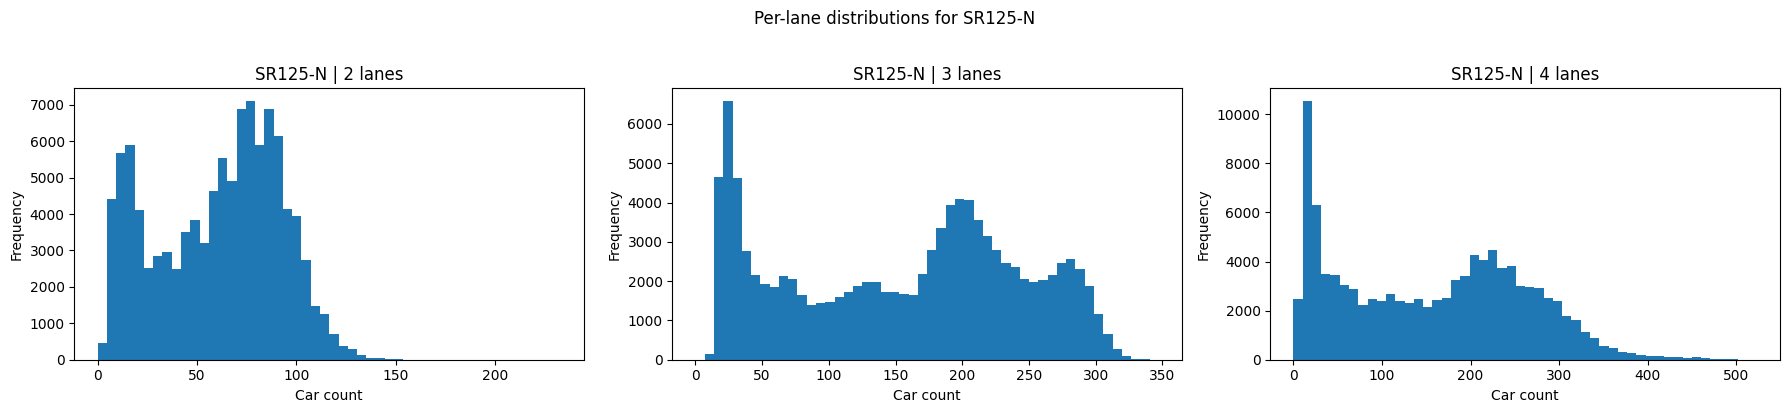

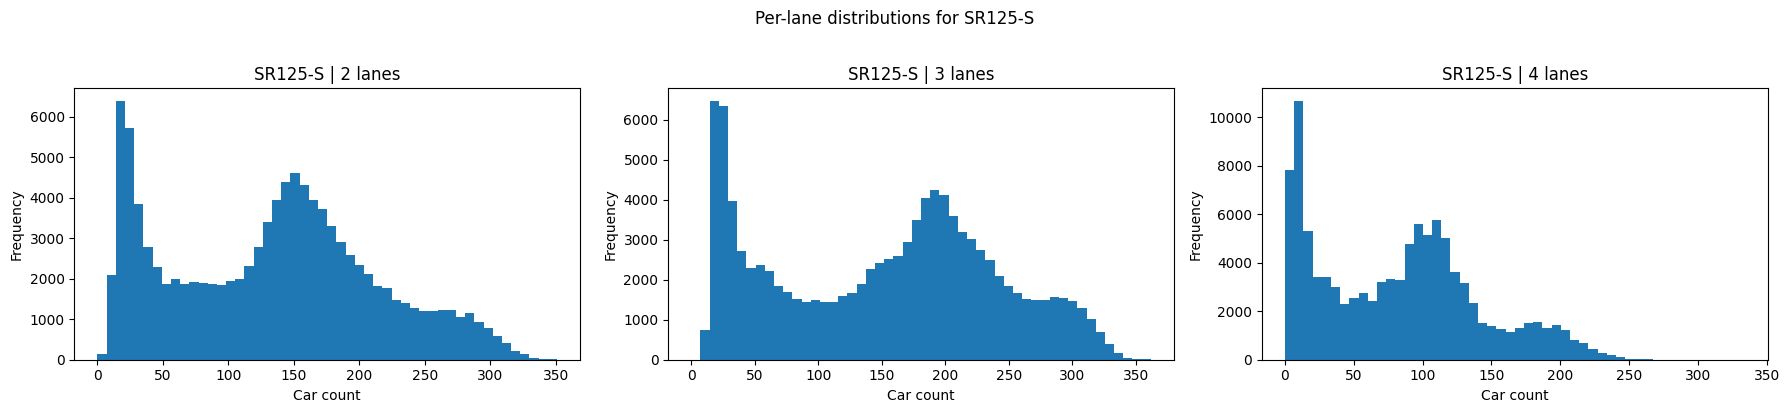

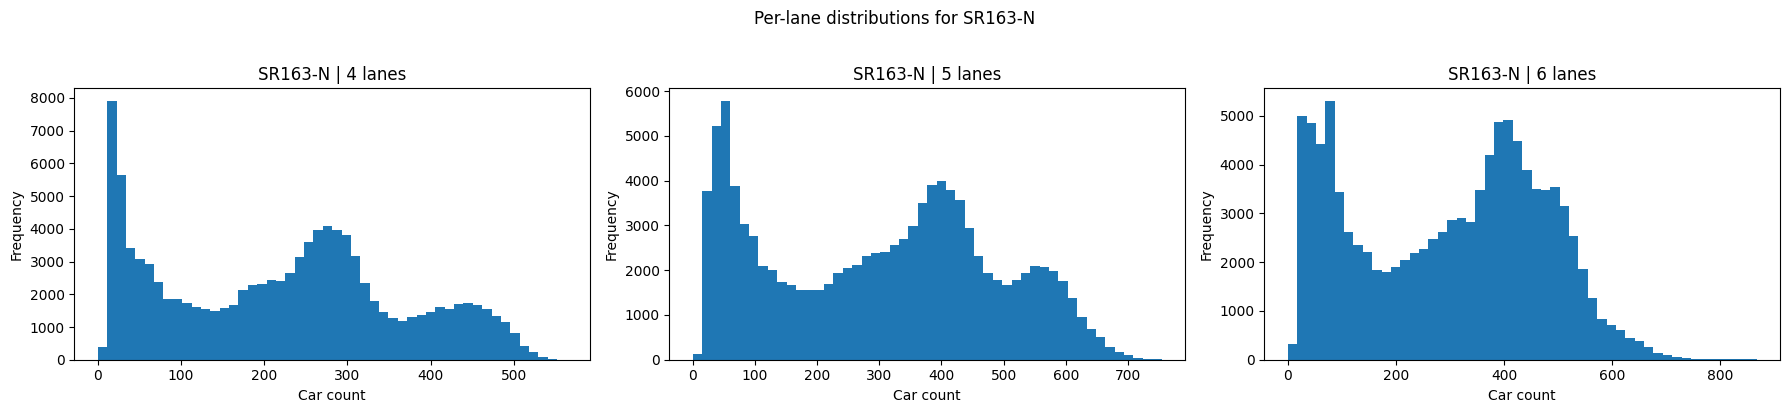

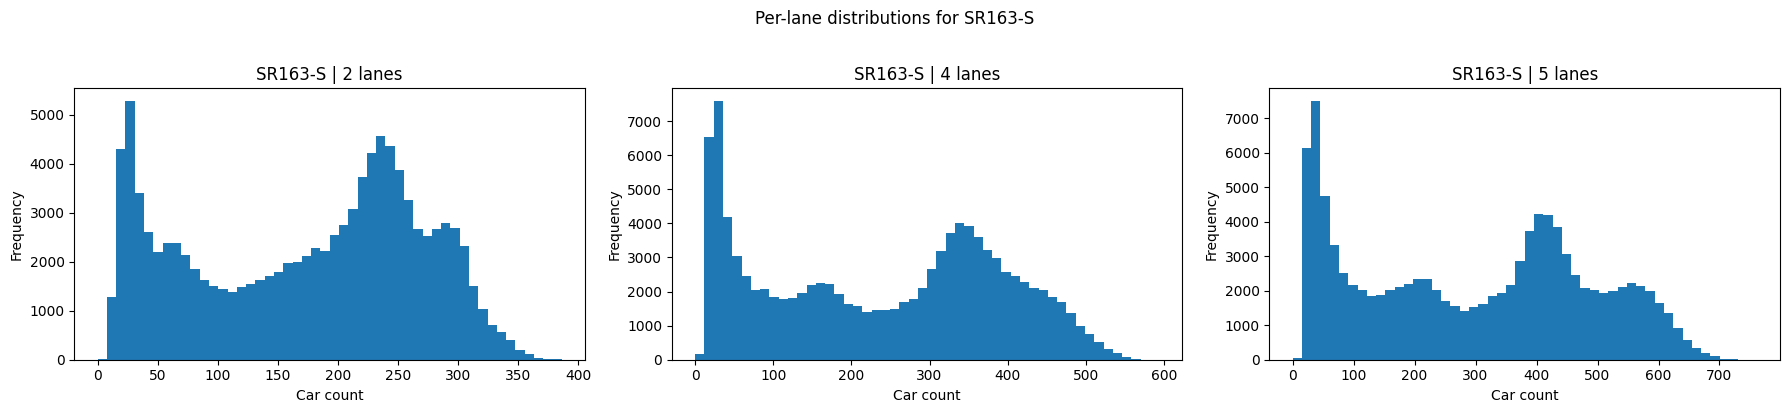

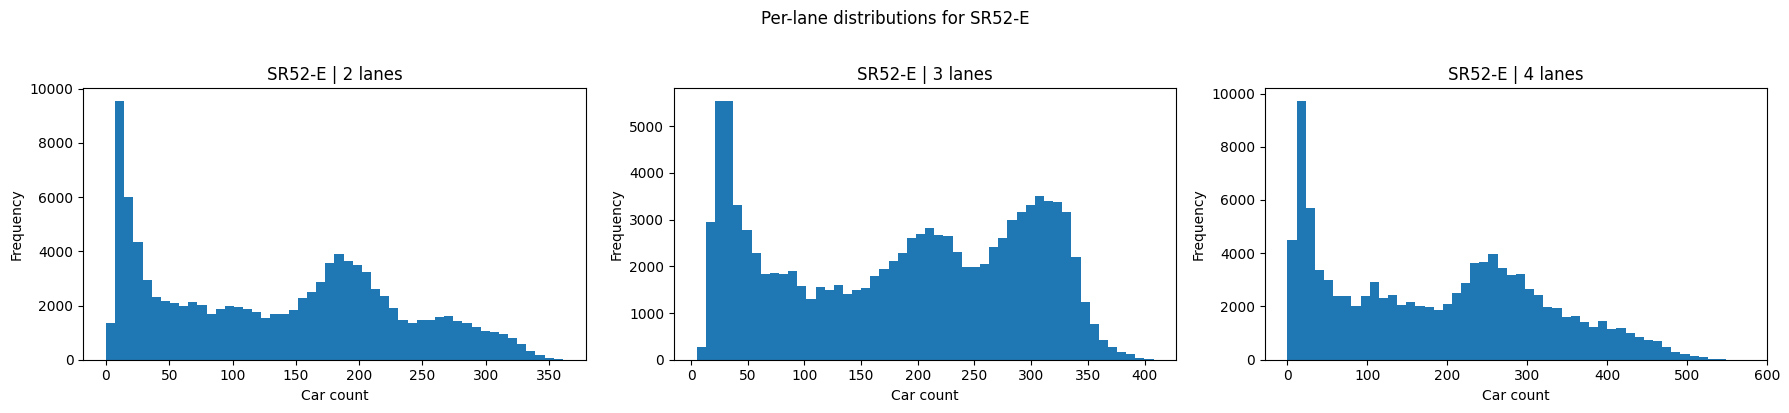

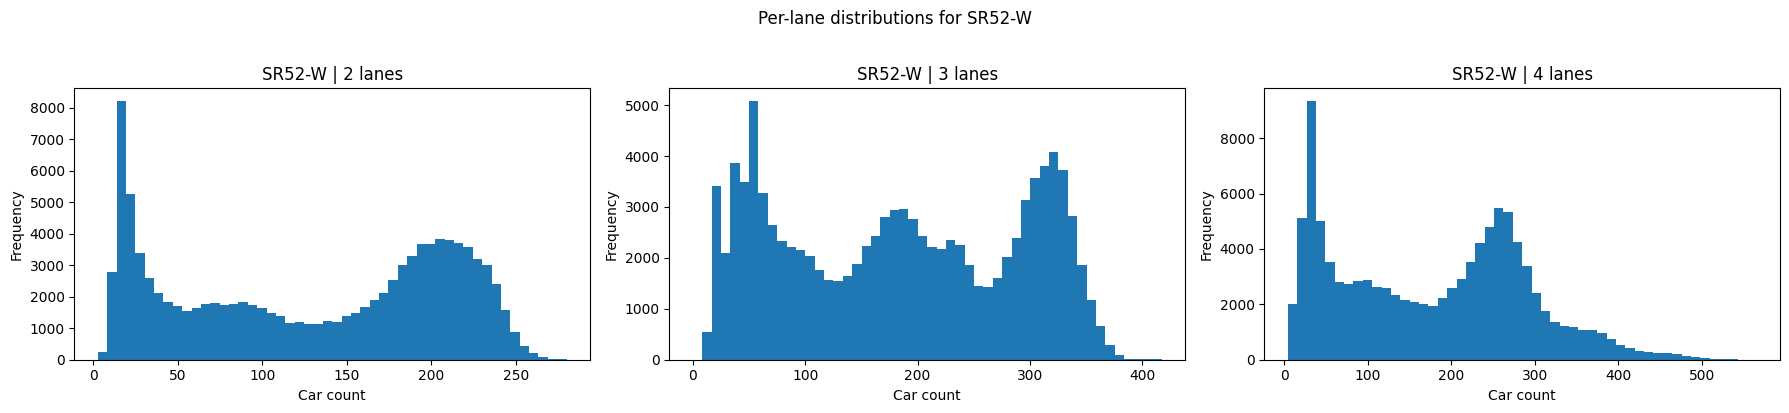

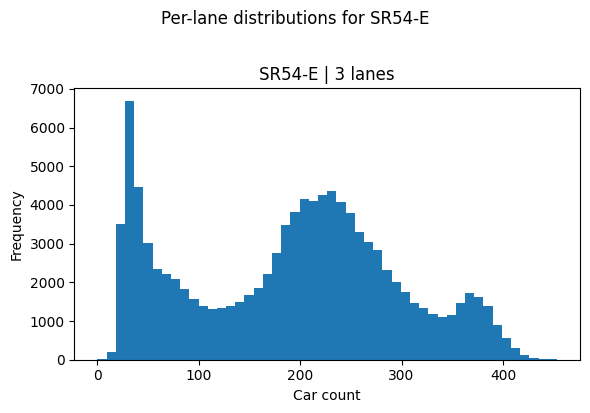

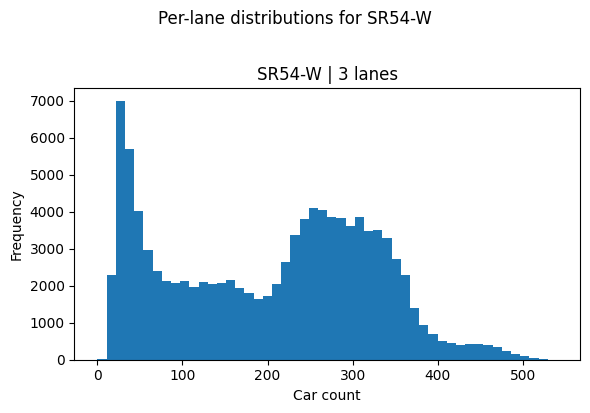

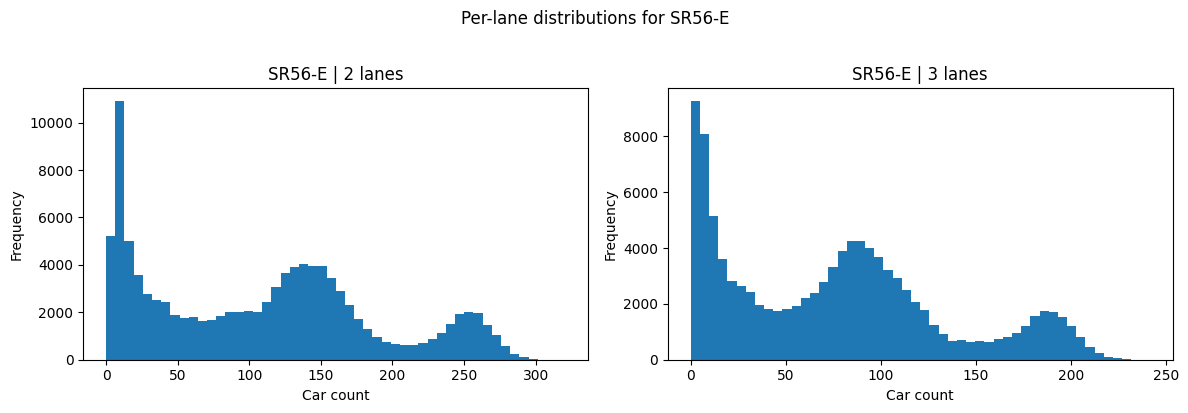

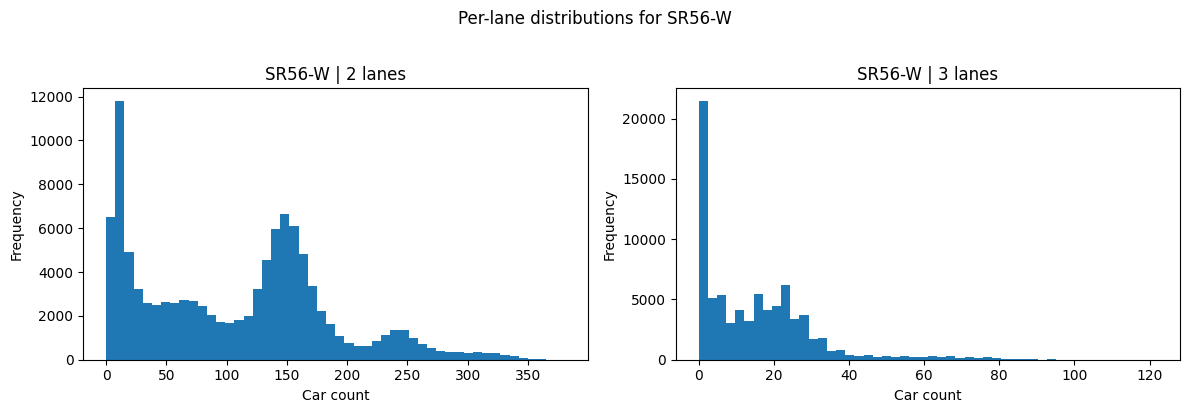

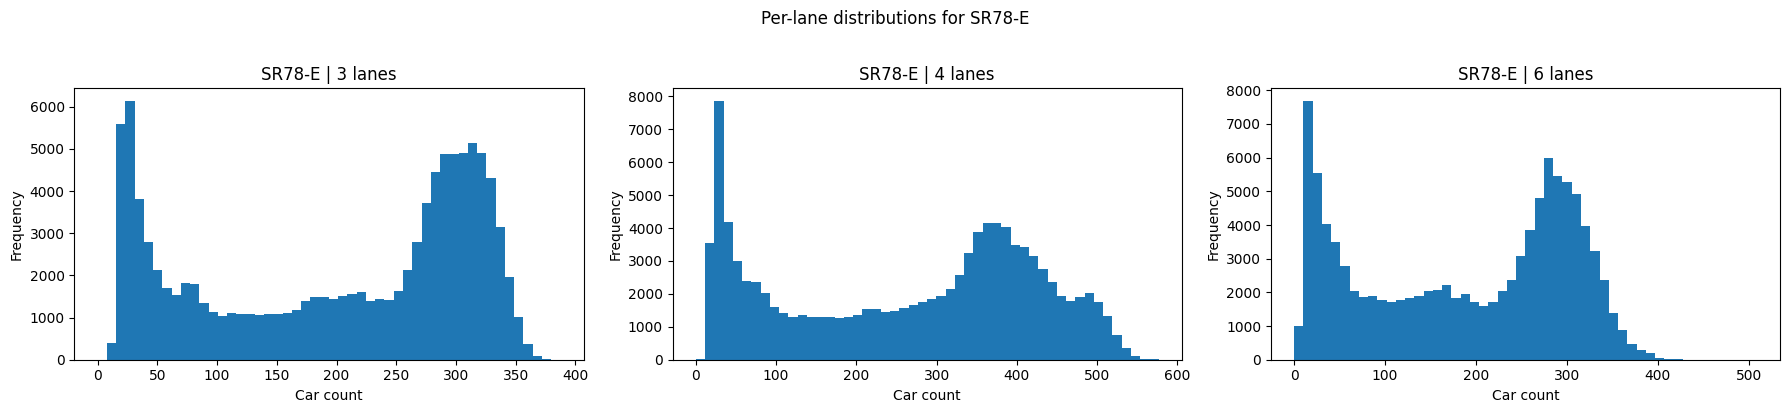

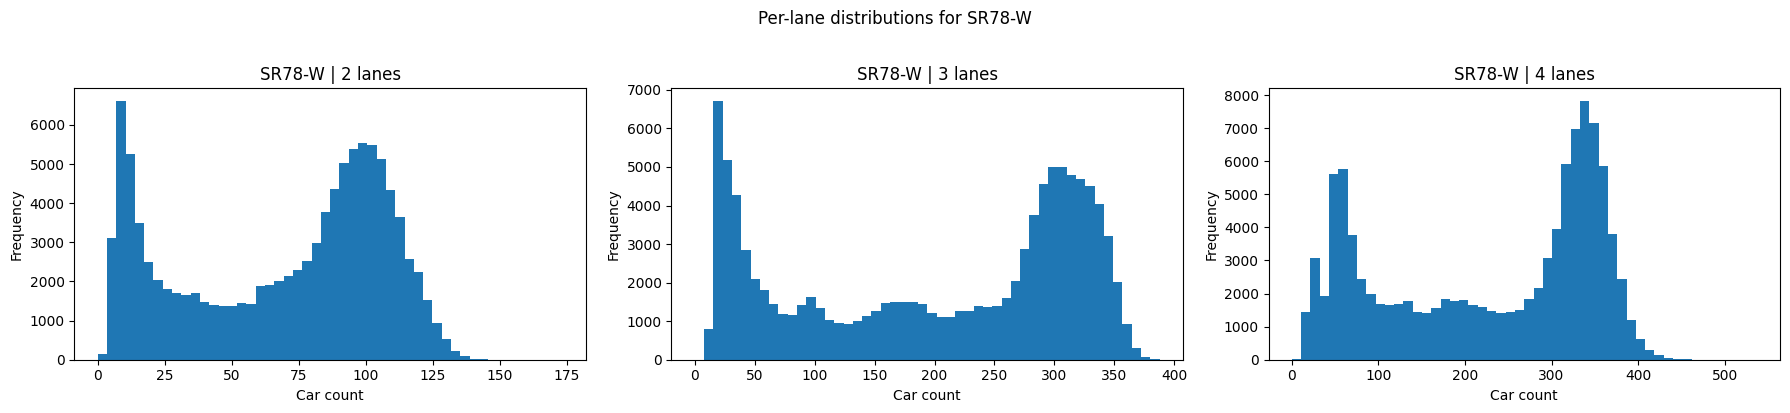

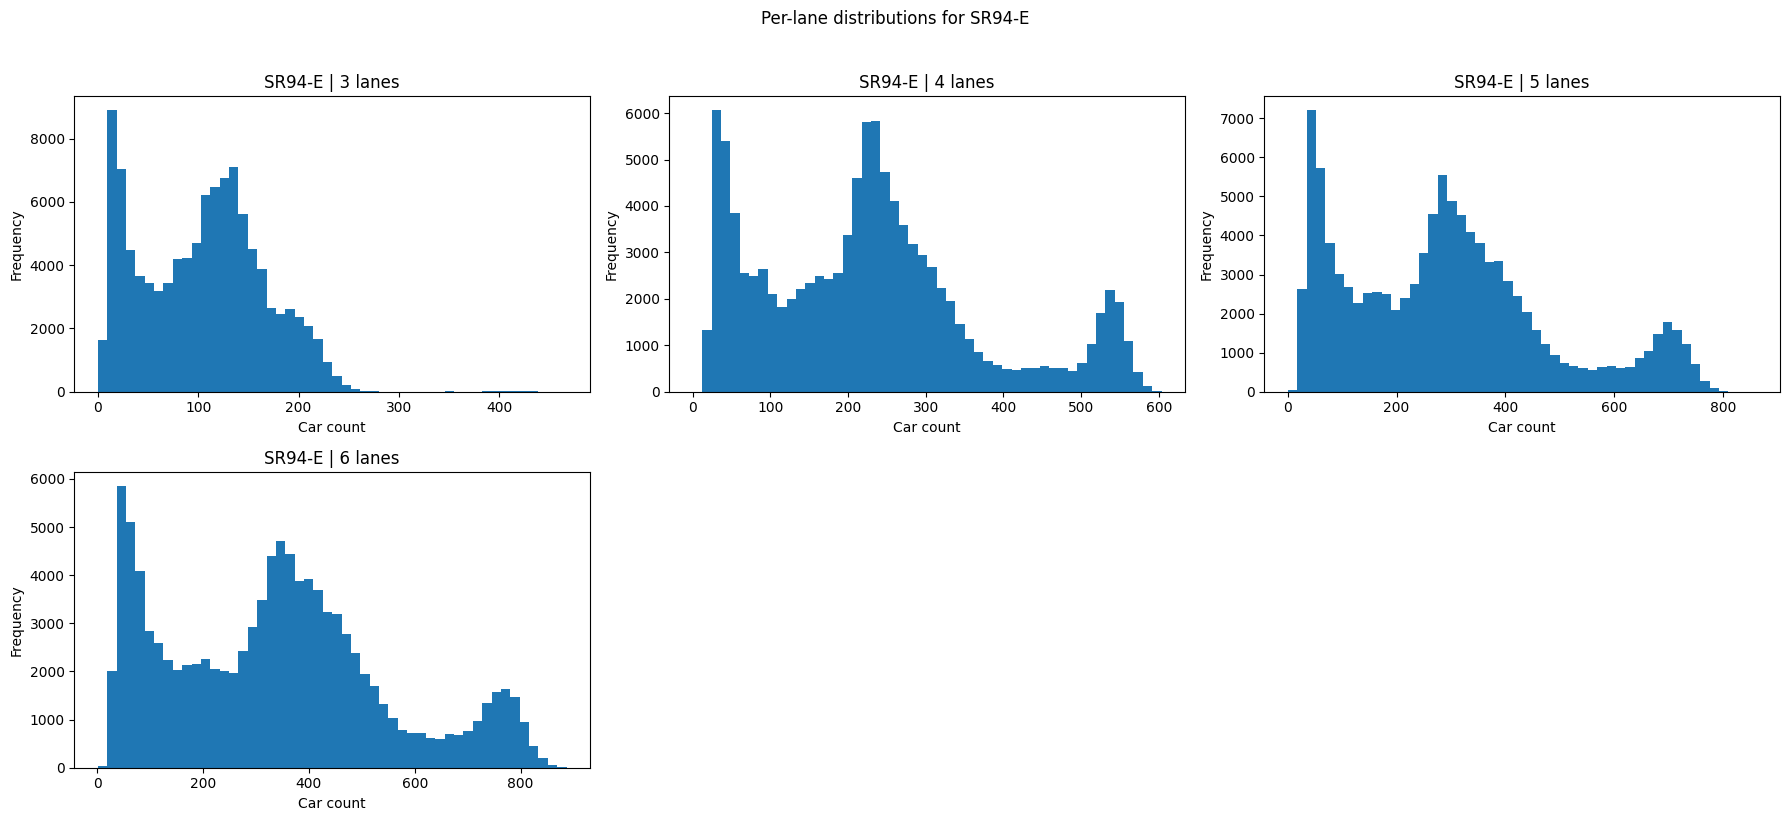

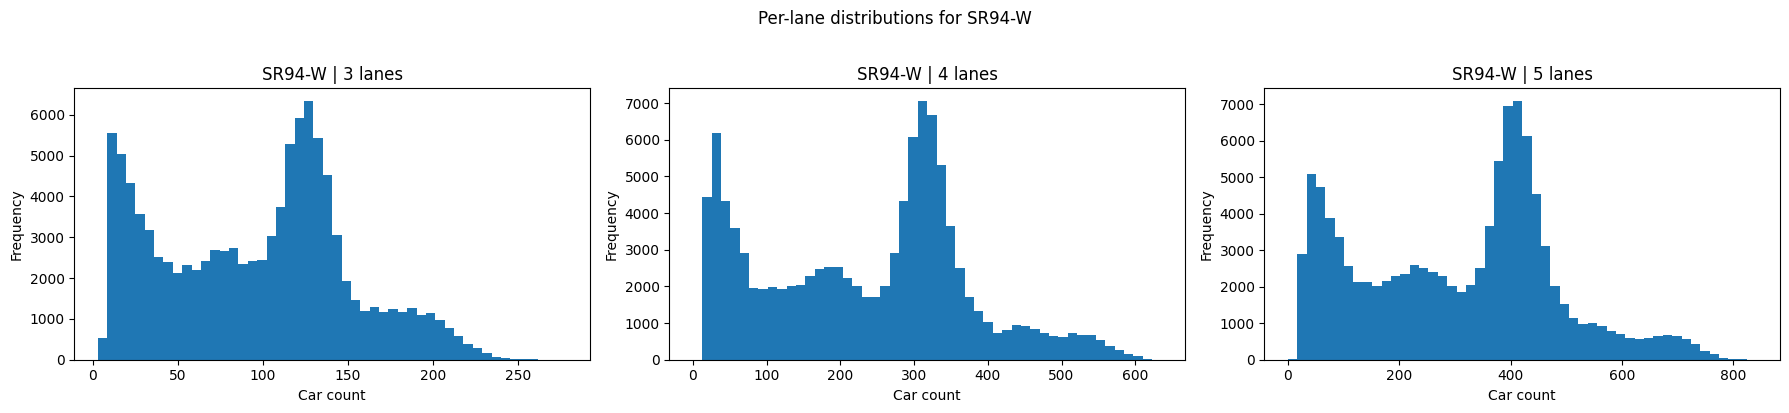

In [106]:
for fwy in collapsed_by_lane.columns.get_level_values("Fwy").unique():
    fwy_data = collapsed_by_lane[fwy]

    lane_counts = sorted(fwy_data.columns.unique())
    n = len(lane_counts)

    ncols = min(3, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, lane in zip(axes, lane_counts):
        series = fwy_data[lane].dropna()

        ax.hist(series, bins=50)
        ax.set_title(f"{fwy} | {lane} lanes")
        ax.set_xlabel("Car count")
        ax.set_ylabel("Frequency")

    for ax in axes[len(lane_counts):]:
        ax.axis("off")

    fig.suptitle(f"Per-lane distributions for {fwy}", y=1.02)
    plt.tight_layout()
    plt.show()